Step 1: remove missing values 

In [2]:
import pandas as pd
from matplotlib import pyplot as plt

In [12]:
# Load the fred_qd_jan2025 dataset
fred_qd_jan2025 = pd.read_csv("FRED_QD_jan2025.csv", index_col=0, parse_dates=True).iloc[2:]
fred_qd_current= pd.read_csv("FRED_QD.csv", index_col=0, parse_dates=True).iloc[2:]

fred_qd_jan2025.index = pd.to_datetime(fred_qd_jan2025.index, format="%m/%d/%Y")
fred_qd_current.index = pd.to_datetime(fred_qd_current.index, format="%m/%d/%Y")

print("Columns:")
print(fred_qd_jan2025.columns)
print(fred_qd_current.columns)
print("Same columns?", fred_qd_jan2025.columns.equals(fred_qd_current.columns))
print(fred_qd_jan2025.index[-1])
print(fred_qd_current.index[-1])

# Compare the two DataFrames
are_equal = fred_qd_current.equals(fred_qd_jan2025)
print(f"Are fred_qd (minus one row) and fred_qd_jan2025 the same? {are_equal}")

# Print the difference between the two DataFrames
diff = fred_qd_current.compare(fred_qd_jan2025)
print("Difference between the two DataFrames:")
print(diff)

Columns:
Index(['GDPC1', 'PCECC96', 'PCDGx', 'PCESVx', 'PCNDx', 'GPDIC1', 'FPIx',
       'Y033RC1Q027SBEAx', 'PNFIx', 'PRFIx',
       ...
       'TNWMVBSNNCBBDIx', 'TLBSNNBx', 'TLBSNNBBDIx', 'TABSNNBx', 'TNWBSNNBx',
       'TNWBSNNBBDIx', 'CNCFx', 'S&P 500', 'S&P div yield', 'S&P PE ratio'],
      dtype='object', length=245)
Index(['GDPC1', 'PCECC96', 'PCDGx', 'PCESVx', 'PCNDx', 'GPDIC1', 'FPIx',
       'Y033RC1Q027SBEAx', 'PNFIx', 'PRFIx',
       ...
       'TNWMVBSNNCBBDIx', 'TLBSNNBx', 'TLBSNNBBDIx', 'TABSNNBx', 'TNWBSNNBx',
       'TNWBSNNBBDIx', 'CNCFx', 'S&P 500', 'S&P div yield', 'S&P PE ratio'],
      dtype='object', length=245)
Same columns? True
2024-12-01 00:00:00
2024-12-01 00:00:00
Are fred_qd (minus one row) and fred_qd_jan2025 the same? False
Difference between the two DataFrames:
                GDPC1               PCECC96                PCDGx             \
                 self      other       self      other      self      other   
sasdate                            

C:\Users\giada\AppData\Local\Temp\ipykernel_41472\287010874.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fred_qd_jan2025 = pd.read_csv("FRED_QD_jan2025.csv", index_col=0, parse_dates=True).iloc[2:]
C:\Users\giada\AppData\Local\Temp\ipykernel_41472\287010874.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fred_qd_current= pd.read_csv("FRED_QD.csv", index_col=0, parse_dates=True).iloc[2:]


In [3]:


# Load the datasets
fred_md = pd.read_csv("FRED_MD.csv", index_col=0, parse_dates=True, date_format="%m/%d/%Y")
fred_qd = pd.read_csv("FRED_QD.csv", index_col=0, parse_dates=True, date_format="%m/%d/%Y")

# Drop metadata rows (first row for MD, first two for QD)
fred_md = fred_md.iloc[1:].apply(pd.to_numeric, errors='coerce')
fred_qd = fred_qd.iloc[2:].apply(pd.to_numeric, errors='coerce')

# Convert index to datetime (if not already)
fred_md.index = pd.to_datetime(fred_md.index)
fred_qd.index = pd.to_datetime(fred_qd.index)

# Drop values after 2019
fred_md = fred_md.loc[:'2024-06-30']
fred_qd = fred_qd.loc[:'2024-06-30']

if fred_md.index[-1] > pd.to_datetime('2020-03-01'):
    # Replace values in columns 'CP3Mx', 'COMPAPFFx' of fred_md at 2020-04-01 with the average of the previous and next values
    for col in ['CP3Mx', 'COMPAPFFx']:
        idx = fred_md.index.get_loc(pd.to_datetime('2020-04-01'))
        avg_value = (fred_md[col].iloc[idx - 1] + fred_md[col].iloc[idx + 1]) / 2
        fred_md.at[pd.to_datetime('2020-04-01'), col] = avg_value

# Remove features from qd if they are also in qd
overlapping_columns = set(fred_md.columns).intersection(set(fred_qd.columns))

print("Overlapping columns between FRED_md and FRED_qd:")
print(overlapping_columns)

# Drop overlapping columns from fred_qd
fred_qd = fred_qd.drop(columns=overlapping_columns)

# Check the result
print("Remaining columns in FRED_qd after removing overlapping columns with FRED_md:")
print(fred_qd.columns)


# Step 1: Remove features with more than 5% missing values
threshold = 0.05
fred_md_filtered = fred_md.loc[:, fred_md.isnull().mean() <= threshold]
fred_qd_filtered = fred_qd.loc[:, fred_qd.isnull().mean() <= threshold]

# Check missing values after removing features
print("Missing values in FRED_md after removing features with >5% missing values:")
print(fred_md_filtered.isnull().sum().sum())

print("Missing values in FRED_qd after removing features with >5% missing values:")
print(fred_qd_filtered.isnull().sum().sum())

# Step 2: Remove rows with any missing values
# fred_md_cleaned = fred_md_filtered.dropna()
# fred_qd_cleaned = fred_qd_filtered.dropna()

# Find latest data of any missing value
# ... for md
latest_md = fred_md_filtered[fred_md_filtered.isnull().any(axis=1)].index.max()
print(f"Latest date with missing values in FRED_md: {latest_md}")

# ... for qd
latest_qd = fred_qd_filtered[fred_qd_filtered.isnull().any(axis=1)].index.max()
print(f"Latest date with missing values in FRED_qd: {latest_qd}")

latest_overall = max(latest_md, latest_qd)
month_after_latest = latest_overall + pd.DateOffset(months=1)

print("Keeping values at and after:", month_after_latest)

fred_md_cleaned = fred_md_filtered.loc[month_after_latest:]
fred_qd_cleaned = fred_qd_filtered.loc[month_after_latest:]

# Check the result
print("Total remaining rows in FRED_md:", len(fred_md_cleaned))
print("Total remaining rows in FRED_qd:", len(fred_qd_cleaned))

# Check if there are still missing values in the cleaned datasets
missing_values_md = fred_md_cleaned.isnull().sum().sum()
missing_values_qd = fred_qd_cleaned.isnull().sum().sum()

print(f"Missing values in the cleaned FRED_md dataset: {missing_values_md}")
print(f"Missing values in the cleaned FRED_qd dataset: {missing_values_qd}")

# Save the cleaned datasets if needed
fred_md_cleaned.to_csv('FRED_md_cleaned.csv', index=True)
fred_qd_cleaned.to_csv('FRED_qd_cleaned.csv', index=True)

Overlapping columns between FRED_md and FRED_qd:
{'TB6MS', 'IPFUELS', 'NONBORRES', 'CLAIMSx', 'USTRADE', 'SRVPRD', 'IPDMAT', 'EXUSUKx', 'UEMPMEAN', 'PPICMM', 'IPNCONGD', 'S&P PE ratio', 'BAA', 'AAA', 'AMDMNOx', 'EXCAUSx', 'OILPRICEx', 'USWTRADE', 'PERMITW', 'IPFINAL', 'UMCSENTx', 'CUMFNS', 'USGOOD', 'S&P div yield', 'INVEST', 'CUSR0000SA0L5', 'USGOVT', 'HOUST', 'WPSID61', 'WPSID62', 'CUSR0000SAC', 'PERMITNE', 'DTCOLNVHFNM', 'TOTRESNS', 'VIXCLSx', 'PAYEMS', 'BUSINVx', 'HOUSTS', 'T5YFFM', 'PERMITMW', 'CUSR0000SA0L2', 'ISRATIOx', 'TB3MS', 'DTCTHFNM', 'USFIRE', 'IPMAT', 'IPNMAT', 'IPMANSICS', 'INDPRO', 'TB3SMFFM', 'CPIAUCSL', 'HOUSTNE', 'UEMPLT5', 'M2REAL', 'CPIAPPSL', 'CPIULFSL', 'UEMP27OV', 'USTPU', 'IPCONGD', 'AAAFFM', 'FEDFUNDS', 'GS5', 'IPB51222S', 'UNRATE', 'TWEXAFEGSMTHx', 'USCONS', 'CUSR0000SAS', 'CPITRNSL', 'UEMP15T26', 'CE16OV', 'AWOTMAN', 'CUSR0000SAD', 'WPSFD49502', 'IPBUSEQ', 'GS1', 'DMANEMP', 'CES0600000007', 'S&P 500', 'PERMIT', 'HOUSTW', 'CMRMTSPLx', 'AMDMUOx', 'EXJPUSx', '

How many features are non-stationary in the raw dataset?

Running ADF tests on FRED-MD dataset...
Running ADF tests on FRED-QD dataset...

FRED-MD Results:
Total features: 121
Non-stationary features: 92
Percentage non-stationary: 76.03%

FRED-QD Results:
Total features: 117
Non-stationary features: 102
Percentage non-stationary: 87.18%


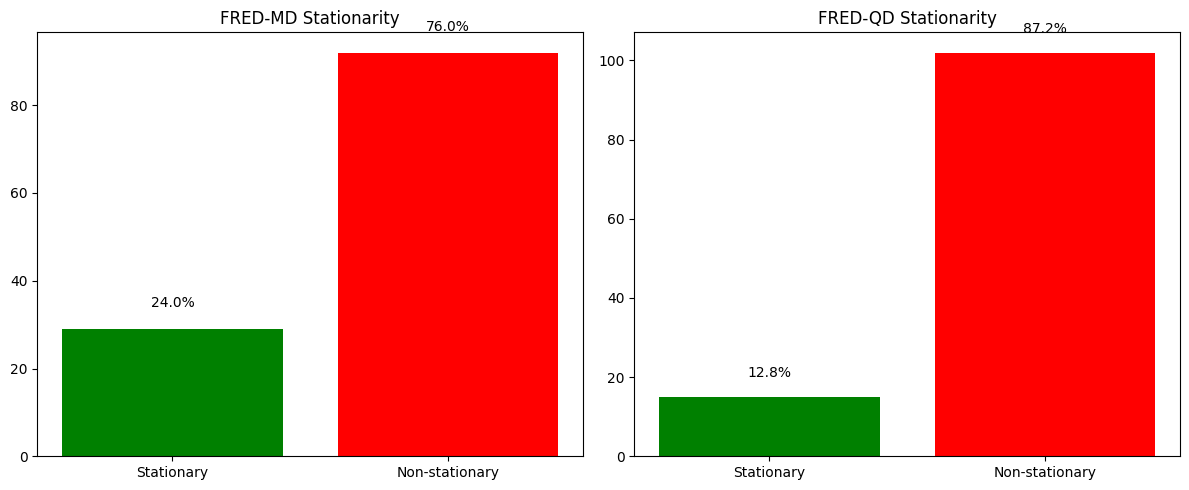


Examples of non-stationary features in FRED-MD:
  - RPI (p-value: 0.9991)
  - W875RX1 (p-value: 0.9990)
  - DPCERA3M086SBEA (p-value: 1.0000)
  - CMRMTSPLx (p-value: 0.9780)
  - RETAILx (p-value: 0.9991)

Examples of non-stationary features in FRED-QD:
  - GDPC1 (p-value: 0.9991)
  - PCECC96 (p-value: 1.0000)
  - PCDGx (p-value: 1.0000)
  - PCESVx (p-value: 0.9983)
  - PCNDx (p-value: 0.9990)


In [4]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Load the cleaned datasets
fred_md_cleaned = pd.read_csv("FRED_md_cleaned.csv", index_col=0, parse_dates=True)
fred_qd_cleaned = pd.read_csv("FRED_qd_cleaned.csv", index_col=0, parse_dates=True)

# Function to perform ADF test on each feature
def check_stationarity(dataframe, significance_level=0.05):
    results = {}
    non_stationary_count = 0
    
    for column in dataframe.columns:
        try:
            # Perform ADF test
            adf_result = adfuller(dataframe[column].dropna())
            p_value = adf_result[1]
            
            # Check if non-stationary
            is_stationary = p_value < significance_level
            results[column] = {
                'p_value': p_value,
                'is_stationary': is_stationary
            }
            
            if not is_stationary:
                non_stationary_count += 1
                
        except Exception as e:
            print(f"Error testing column {column}: {e}")
            results[column] = {
                'p_value': None,
                'is_stationary': None
            }
    
    non_stationary_percentage = (non_stationary_count / len(dataframe.columns)) * 100
    return results, non_stationary_count, non_stationary_percentage

# Perform ADF tests on both datasets
print("Running ADF tests on FRED-MD dataset...")
md_results, md_non_stationary_count, md_non_stationary_percentage = check_stationarity(fred_md_cleaned)

print("Running ADF tests on FRED-QD dataset...")
qd_results, qd_non_stationary_count, qd_non_stationary_percentage = check_stationarity(fred_qd_cleaned)

# Display results
print(f"\nFRED-MD Results:")
print(f"Total features: {len(fred_md_cleaned.columns)}")
print(f"Non-stationary features: {md_non_stationary_count}")
print(f"Percentage non-stationary: {md_non_stationary_percentage:.2f}%")

print(f"\nFRED-QD Results:")
print(f"Total features: {len(fred_qd_cleaned.columns)}")
print(f"Non-stationary features: {qd_non_stationary_count}")
print(f"Percentage non-stationary: {qd_non_stationary_percentage:.2f}%")

# Plot the results
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# MD dataset
ax[0].bar(['Stationary', 'Non-stationary'], 
          [len(fred_md_cleaned.columns) - md_non_stationary_count, md_non_stationary_count],
          color=['green', 'red'])
ax[0].set_title('FRED-MD Stationarity')
ax[0].text(0, len(fred_md_cleaned.columns) - md_non_stationary_count + 5, 
           f"{100 - md_non_stationary_percentage:.1f}%", 
           ha='center')
ax[0].text(1, md_non_stationary_count + 5, 
           f"{md_non_stationary_percentage:.1f}%", 
           ha='center')

# QD dataset
ax[1].bar(['Stationary', 'Non-stationary'], 
          [len(fred_qd_cleaned.columns) - qd_non_stationary_count, qd_non_stationary_count],
          color=['green', 'red'])
ax[1].set_title('FRED-QD Stationarity')
ax[1].text(0, len(fred_qd_cleaned.columns) - qd_non_stationary_count + 5, 
           f"{100 - qd_non_stationary_percentage:.1f}%", 
           ha='center')
ax[1].text(1, qd_non_stationary_count + 5, 
           f"{qd_non_stationary_percentage:.1f}%", 
           ha='center')

plt.tight_layout()
plt.show()

# List a few examples of non-stationary features
print("\nExamples of non-stationary features in FRED-MD:")
non_stationary_md = [col for col, res in md_results.items() if res['is_stationary'] == False]
for col in non_stationary_md[:5]:
    print(f"  - {col} (p-value: {md_results[col]['p_value']:.4f})")

print("\nExamples of non-stationary features in FRED-QD:")
non_stationary_qd = [col for col, res in qd_results.items() if res['is_stationary'] == False]
for col in non_stationary_qd[:5]:
    print(f"  - {col} (p-value: {qd_results[col]['p_value']:.4f})")

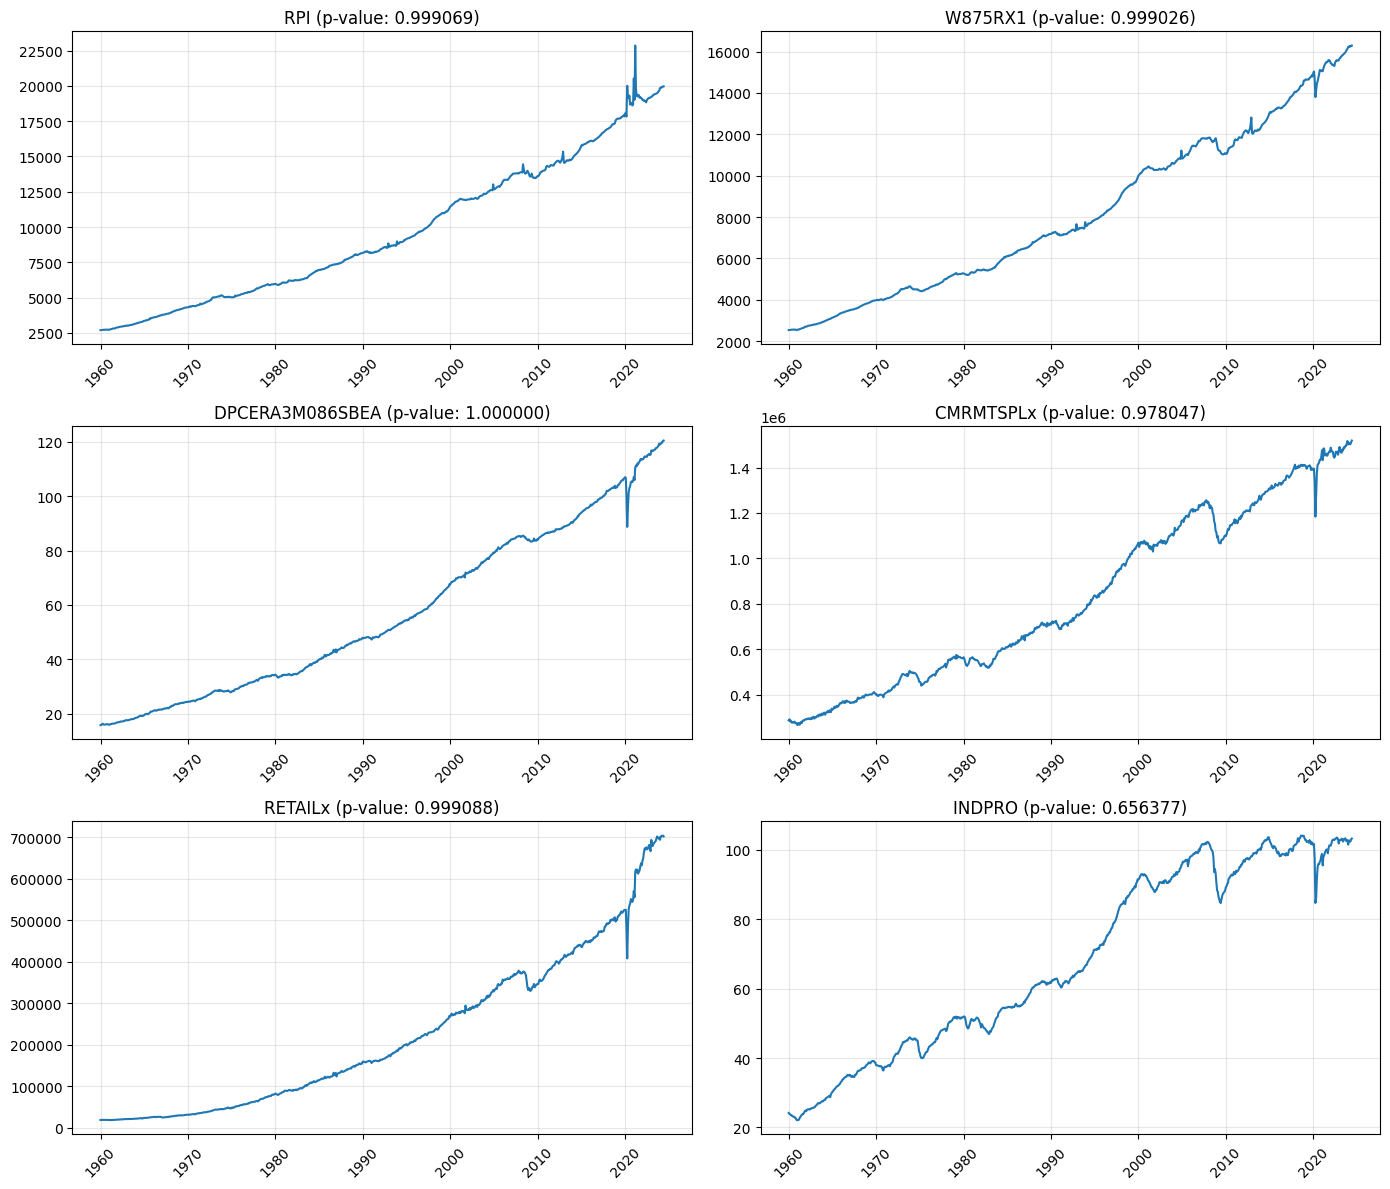

Top 10 Non-Stationary Features from FRED MD dataset:
RPI             p-value: 0.999069
W875RX1         p-value: 0.999026
DPCERA3M086SBEA p-value: 1.000000
CMRMTSPLx       p-value: 0.978047
RETAILx         p-value: 0.999088
INDPRO          p-value: 0.656377
IPFPNSS         p-value: 0.499763
IPFINAL         p-value: 0.509642
IPCONGD         p-value: 0.187231
IPDCONGD        p-value: 0.721346


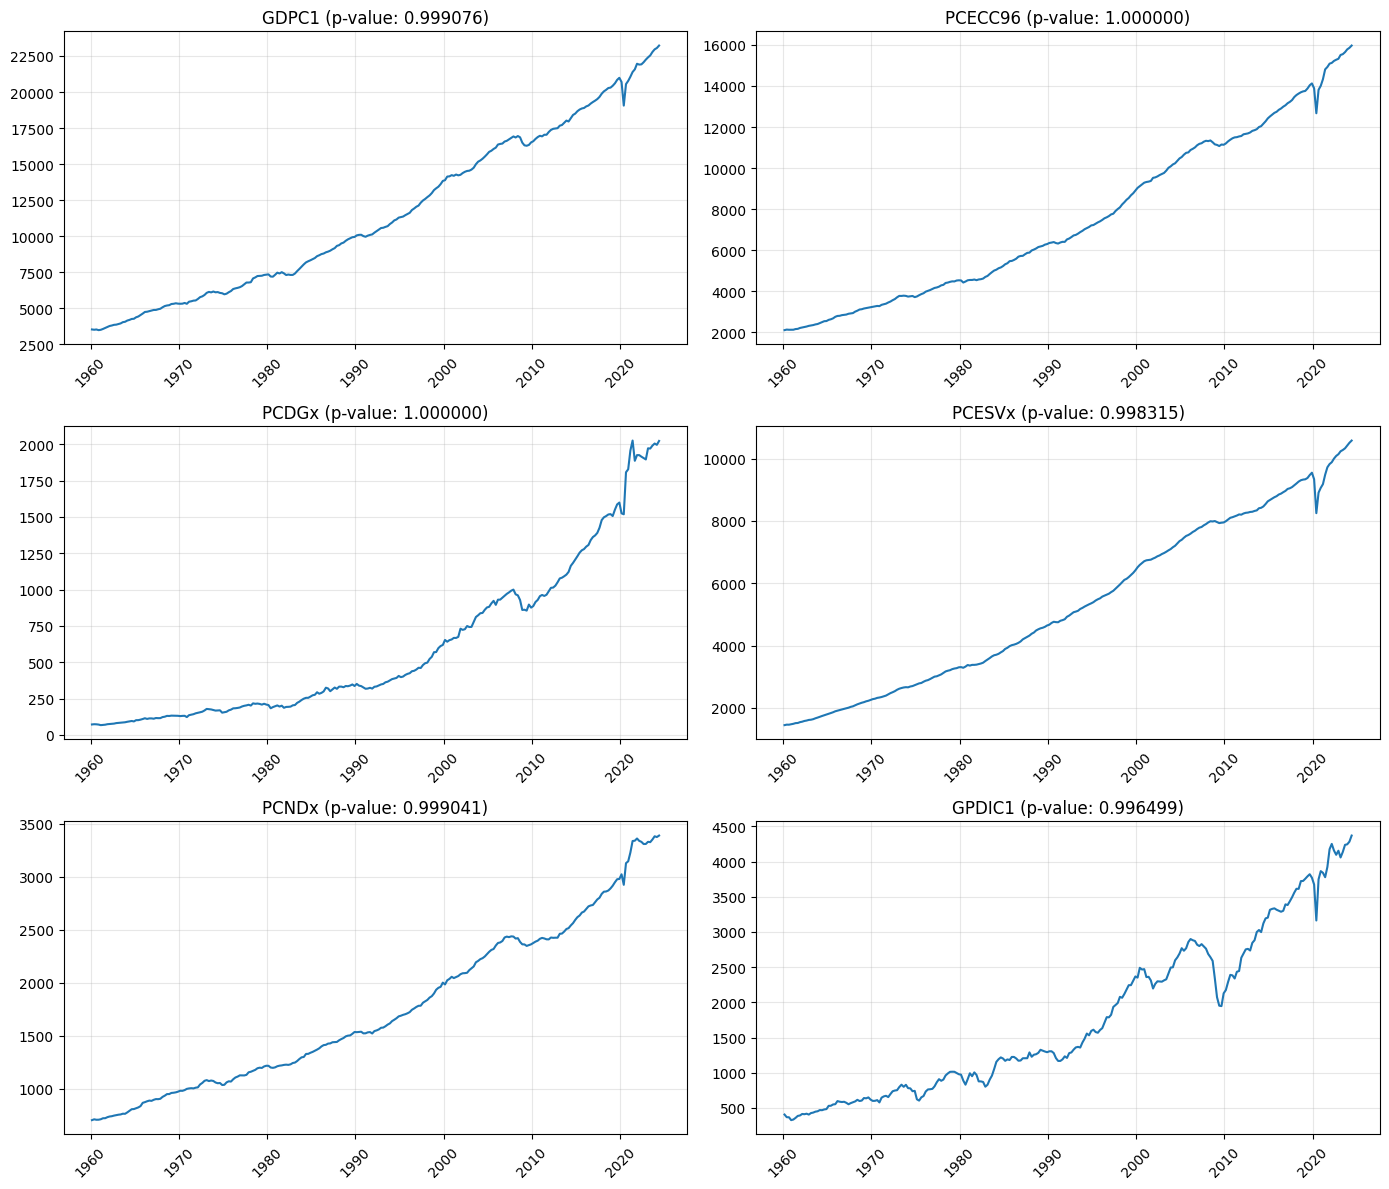


Top 10 Non-Stationary Features from FRED QD dataset:
GDPC1           p-value: 0.999076
PCECC96         p-value: 1.000000
PCDGx           p-value: 1.000000
PCESVx          p-value: 0.998315
PCNDx           p-value: 0.999041
GPDIC1          p-value: 0.996499
FPIx            p-value: 0.995941
Y033RC1Q027SBEAx p-value: 0.994281
PNFIx           p-value: 0.999078
PRFIx           p-value: 0.472863


In [5]:
import numpy as np

# Create subplots for a selection of non-stationary features
import matplotlib.pyplot as plt

# Select a subset of non-stationary features to visualize (e.g., top 6)
features_to_plot = non_stationary_md[:6]  # First 6 non-stationary features from MD dataset

# Set up the figure
fig, axs = plt.subplots(3, 2, figsize=(14, 12))
axs = axs.flatten()

# Plot each selected feature
for i, feature in enumerate(features_to_plot):
    # Get the p-value from the test results
    p_value = md_results[feature]['p_value']
    
    # Plot the time series
    axs[i].plot(fred_md_cleaned.index, fred_md_cleaned[feature])
    
    # Add title with feature name and p-value
    axs[i].set_title(f"{feature} (p-value: {p_value:.6f})")
    
    # Format the plot
    axs[i].grid(True, alpha=0.3)
    axs[i].tick_params(axis='x', rotation=45)
    
# Adjust layout
plt.tight_layout()
plt.show()

# Create a table of non-stationary features with their p-values
non_stationary_data = []

# Get p-values for non-stationary features
for feature in non_stationary_md[:10]:  # Showing top 10 for brevity
    p_value = md_results[feature]['p_value']
    non_stationary_data.append((feature, p_value))

# Print the table
print("Top 10 Non-Stationary Features from FRED MD dataset:")
for feature, p_value in non_stationary_data:
    print(f"{feature:<15} p-value: {p_value:.6f}")

# Do the same for QD dataset
features_to_plot_qd = non_stationary_qd[:6]  # First 6 non-stationary features from QD dataset

# Set up the figure for QD features
fig, axs = plt.subplots(3, 2, figsize=(14, 12))
axs = axs.flatten()

# Plot each selected feature
for i, feature in enumerate(features_to_plot_qd):
    # Get the p-value from the test results
    p_value = qd_results[feature]['p_value']
    
    # Plot the time series
    axs[i].plot(fred_qd_cleaned.index, fred_qd_cleaned[feature])
    
    # Add title with feature name and p-value
    axs[i].set_title(f"{feature} (p-value: {p_value:.6f})")
    
    # Format the plot
    axs[i].grid(True, alpha=0.3)
    axs[i].tick_params(axis='x', rotation=45)
    
# Adjust layout
plt.tight_layout()
plt.show()

# Create a table of non-stationary features with their p-values for QD
non_stationary_data_qd = []

# Get p-values for non-stationary features
for feature in non_stationary_qd[:10]:  # Showing top 10 for brevity
    p_value = qd_results[feature]['p_value']
    non_stationary_data_qd.append((feature, p_value))

# Print the table
print("\nTop 10 Non-Stationary Features from FRED QD dataset:")
for feature, p_value in non_stationary_data_qd:
    print(f"{feature:<15} p-value: {p_value:.6f}")

In [14]:
# Load the datasets
fred_md = pd.read_csv("FRED_MD.csv", index_col=0, parse_dates=True, date_format="%m/%d/%Y")
fred_qd = pd.read_csv("FRED_QD.csv", index_col=0, parse_dates=True, date_format="%m/%d/%Y")

# Drop metadata rows (first row for MD, first two for QD)
fred_md = fred_md.iloc[1:].apply(pd.to_numeric, errors='coerce')
fred_qd = fred_qd.iloc[2:].apply(pd.to_numeric, errors='coerce')

# Convert index to datetime (if not already)
fred_md.index = pd.to_datetime(fred_md.index)
fred_qd.index = pd.to_datetime(fred_qd.index)

# Drop values after 2019
fred_md = fred_md.loc[:'2024-06-30']
fred_qd = fred_qd.loc[:'2024-06-30']

# Remove features from qd if they are also in qd
overlapping_columns = set(fred_md.columns).intersection(set(fred_qd.columns))

print("Overlapping columns between FRED_md and FRED_qd:")
print(overlapping_columns)

# Drop overlapping columns from fred_qd
fred_qd = fred_qd.drop(columns=overlapping_columns)

# Check the result
print("Remaining columns in FRED_qd after removing overlapping columns with FRED_md:")
print(fred_qd.columns)


# Step 1: Remove features with more than 5% missing values
threshold = 0.05
fred_md_filtered = fred_md.loc[:, fred_md.isnull().mean() <= threshold]
fred_qd_filtered = fred_qd.loc[:, fred_qd.isnull().mean() <= threshold]

latest_md_idx = fred_md_filtered[fred_md_filtered.isnull().any(axis=1)].index.max()
print(fred_md_filtered.loc[latest_md_idx].isnull())
latest_md_col = fred_md_filtered.columns[fred_md_filtered.loc[latest_md_idx].isnull()]
latest_md_idx, latest_md_col

Overlapping columns between FRED_md and FRED_qd:
{'EXJPUSx', 'AWHMAN', 'VIXCLSx', 'NDMANEMP', 'DTCOLNVHFNM', 'CPIMEDSL', 'T5YFFM', 'PERMIT', 'PPICMM', 'AAAFFM', 'USTRADE', 'USWTRADE', 'TB3MS', 'IPNCONGD', 'PERMITMW', 'UEMPLT5', 'AWOTMAN', 'CUSR0000SAD', 'TB6MS', 'HOUSTS', 'M2REAL', 'CPIAUCSL', 'SRVPRD', 'IPBUSEQ', 'INVEST', 'IPB51222S', 'HOUSTNE', 'USCONS', 'UEMP5TO14', 'IPFUELS', 'CUSR0000SAC', 'FEDFUNDS', 'AAA', 'USGOVT', 'AMDMNOx', 'IPFINAL', 'USGOOD', 'IPCONGD', 'ISRATIOx', 'CES0600000007', 'TWEXAFEGSMTHx', 'IPMANSICS', 'CPIULFSL', 'GS10', 'AMDMUOx', 'CMRMTSPLx', 'CUSR0000SAS', 'UNRATE', 'GS5', 'GS1', 'HOUST', 'UEMP15T26', 'S&P 500', 'WPSID61', 'USFIRE', 'UEMPMEAN', 'HOUSTMW', 'EXUSUKx', 'IPDCONGD', 'CES0600000008', 'CUMFNS', 'CE16OV', 'INDPRO', 'IPNMAT', 'PERMITNE', 'EXSZUSx', 'IPMAT', 'TB3SMFFM', 'HOUSTW', 'UEMP27OV', 'PAYEMS', 'WPSFD49207', 'CUSR0000SA0L5', 'EXCAUSx', 'DMANEMP', 'S&P div yield', 'S&P PE ratio', 'CPIAPPSL', 'WPSFD49502', 'BAA', 'BUSINVx', 'PERMITW', 'OILPRICEx', 

(Timestamp('2020-04-01 00:00:00'),
 Index(['CP3Mx', 'COMPAPFFx'], dtype='object'))

To fill in these two missing data points, take the average of the datapoint (row) before and after the missing value 

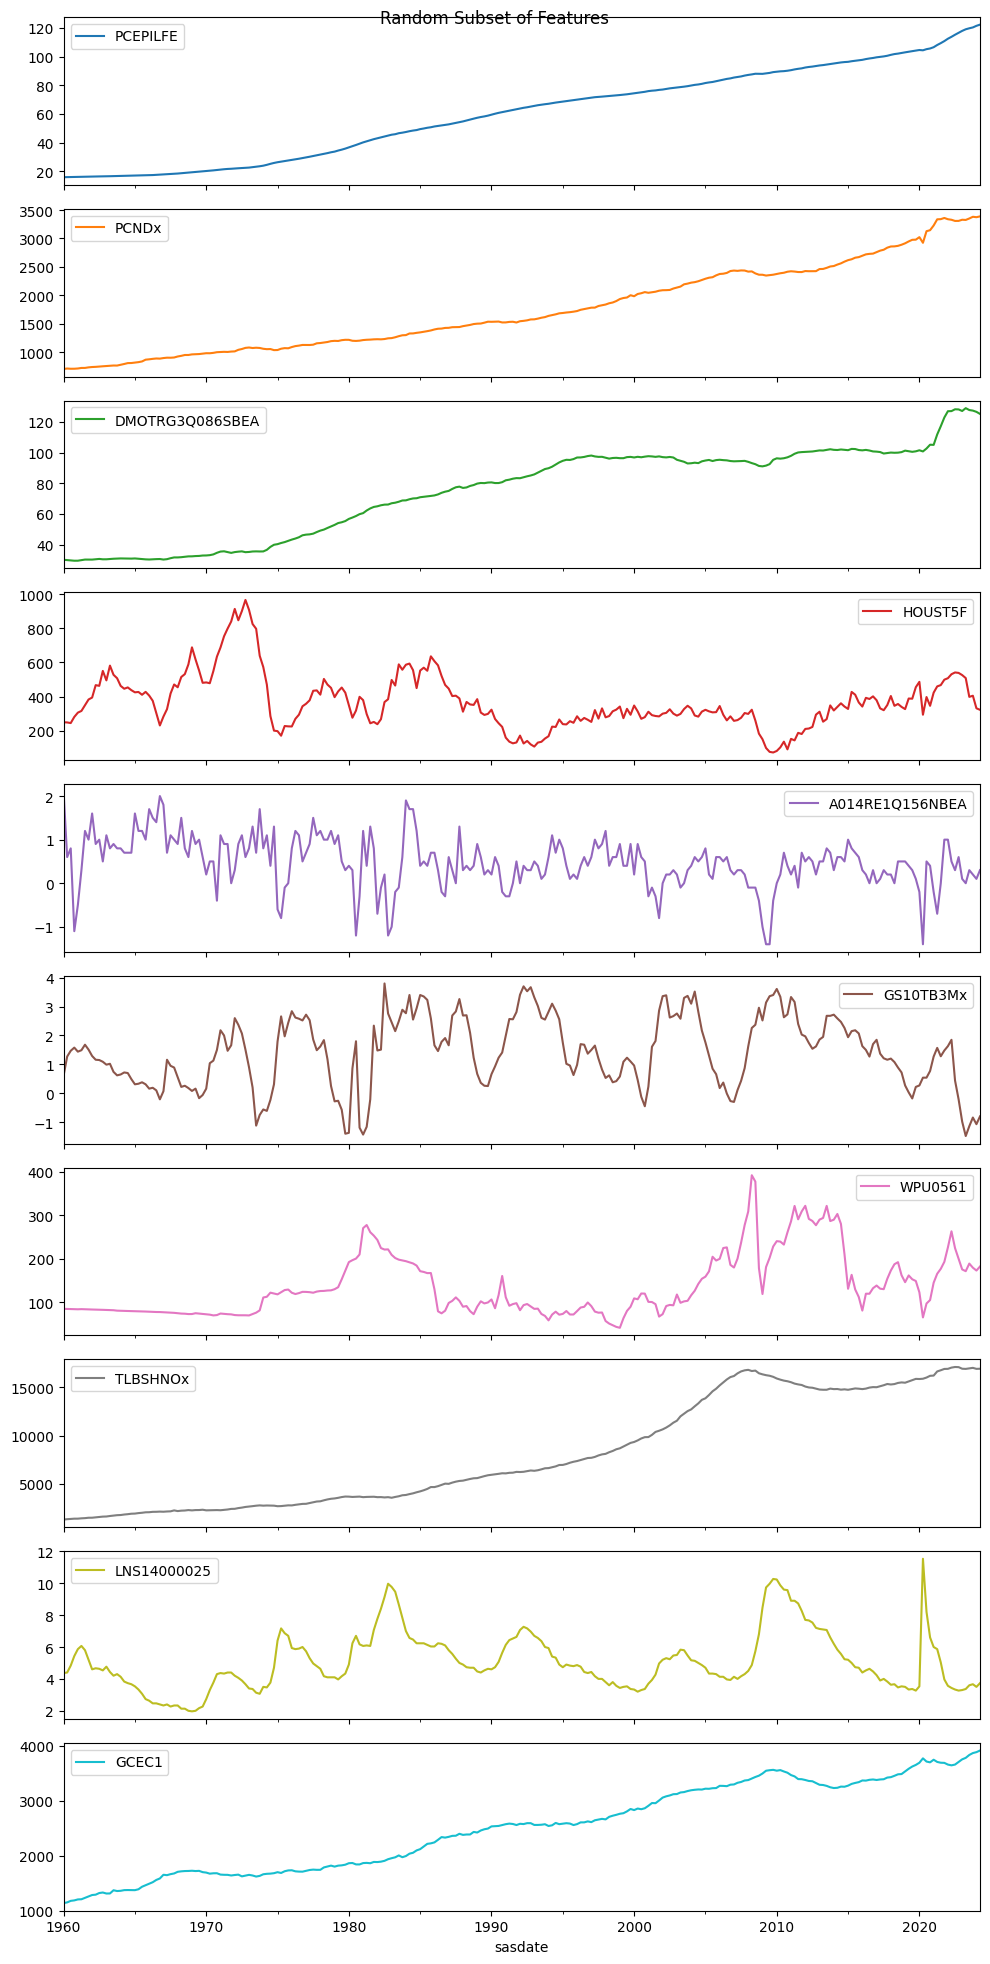

In [146]:
import matplotlib.pyplot as plt

# Plot the random subset of features
random_features = fred_qd_cleaned.sample(n=10, axis=1, random_state=42)
random_features.plot(subplots=True, figsize=(10, 20), title="Random Subset of Features")
plt.tight_layout()
plt.show()

Cleaned dataset: Transform and remove missing values 

In [15]:
import pandas as pd

# Load the datasets
fred_md = pd.read_csv("Fred_md_transformed.csv", index_col=0, parse_dates=True, date_format="%m/%d/%Y", )
fred_qd = pd.read_csv("Fred_qd_transformed.csv", index_col=0, parse_dates=True, date_format="%m/%d/%Y", )

# Drop metadata rows (first row for MD, first two for QD)
fred_md = fred_md.iloc[1:].apply(pd.to_numeric, errors='coerce')
fred_qd = fred_qd.iloc[2:].apply(pd.to_numeric, errors='coerce')

# Convert index to datetime (if not already)
fred_md.index = pd.to_datetime(fred_md.index)
fred_qd.index = pd.to_datetime(fred_qd.index)

# Drop values after 2019
fred_md = fred_md.loc[:'2024-06-30']
fred_qd = fred_qd.loc[:'2024-06-30']

# Remove features from qd if they are also in qd
overlapping_columns = set(fred_md.columns).intersection(set(fred_qd.columns))

if fred_md.index[-1] > pd.to_datetime('2020-03-01'):
    # Replace values in columns 'CP3Mx', 'COMPAPFFx' of fred_md at 2020-(03,04,05)-01 with the average of the previous and next values
    for col in ['CP3Mx', 'COMPAPFFx']:
        avg_value = (fred_md[col].loc['2020-02-01'] + fred_md[col].loc['2020-06-01']) / 2

        for date_str in ['2020-03-01', '2020-04-01', '2020-05-01']:
            fred_md.at[pd.to_datetime(date_str), col] = avg_value

print("Overlapping columns between FRED_md and FRED_qd:")
print(overlapping_columns)

# Drop overlapping columns from fred_qd
fred_qd = fred_qd.drop(columns=overlapping_columns)

# Check the result
print("Remaining columns in FRED_qd after removing overlapping columns with FRED_md:")
print(fred_qd.columns)

# Step 1: Remove features with more than 5% missing values
threshold = 0.05
fred_md_filtered = fred_md.loc[:, fred_md.isnull().mean() <= threshold]
fred_qd_filtered = fred_qd.loc[:, fred_qd.isnull().mean() <= threshold]

# Check missing values after removing features
print("Missing values in FRED_md after removing features with >5% missing values:")
print(fred_md_filtered.isnull().sum().sum())

print("Missing values in FRED_qd after removing features with >5% missing values:")
print(fred_qd_filtered.isnull().sum().sum())

# Step 2: Remove rows with any missing values
# fred_md_cleaned = fred_md_filtered.dropna()
# fred_qd_cleaned = fred_qd_filtered.dropna()

# Find latest data of any missing value
# ... for md
latest_md = fred_md_filtered[fred_md_filtered.isnull().any(axis=1)].index.max()
print(f"Latest date with missing values in FRED_md: {latest_md}")

# ... for qd
latest_qd = fred_qd_filtered[fred_qd_filtered.isnull().any(axis=1)].index.max()
print(f"Latest date with missing values in FRED_qd: {latest_qd}")

latest_overall = max(latest_md, latest_qd)
month_after_latest = latest_overall + pd.DateOffset(months=1)

print("Keeping values at and after:", month_after_latest)

fred_md_cleaned_transformed = fred_md_filtered.loc[month_after_latest:]
fred_qd_cleaned_transformed = fred_qd_filtered.loc[month_after_latest:]

# Check the result
print("Total remaining rows in FRED_md:", len(fred_md_cleaned_transformed))
print("Total remaining rows in FRED_qd:", len(fred_qd_cleaned_transformed))

# Check if there are still missing values in the cleaned datasets
missing_values_md = fred_md_cleaned_transformed.isnull().sum().sum()
missing_values_qd = fred_qd_cleaned_transformed.isnull().sum().sum()

print(f"Missing values in the cleaned FRED_md dataset: {missing_values_md}")
print(f"Missing values in the cleaned FRED_qd dataset: {missing_values_qd}")

# Save the cleaned datasets if needed
fred_md_cleaned_transformed.to_csv('FRED_md_cleaned_transformed.csv', index=True)
fred_qd_cleaned_transformed.to_csv('FRED_qd_cleaned_transformed.csv', index=True)

Overlapping columns between FRED_md and FRED_qd:
{'EXJPUSx', 'AWHMAN', 'VIXCLSx', 'NDMANEMP', 'DTCOLNVHFNM', 'CPIMEDSL', 'T5YFFM', 'PERMIT', 'PPICMM', 'AAAFFM', 'USTRADE', 'USWTRADE', 'TB3MS', 'IPNCONGD', 'PERMITMW', 'UEMPLT5', 'AWOTMAN', 'CUSR0000SAD', 'TB6MS', 'HOUSTS', 'M2REAL', 'CPIAUCSL', 'SRVPRD', 'IPBUSEQ', 'INVEST', 'IPB51222S', 'HOUSTNE', 'USCONS', 'UEMP5TO14', 'IPFUELS', 'CUSR0000SAC', 'FEDFUNDS', 'AAA', 'USGOVT', 'AMDMNOx', 'IPFINAL', 'USGOOD', 'IPCONGD', 'ISRATIOx', 'CES0600000007', 'TWEXAFEGSMTHx', 'IPMANSICS', 'CPIULFSL', 'GS10', 'AMDMUOx', 'CMRMTSPLx', 'CUSR0000SAS', 'UNRATE', 'GS5', 'GS1', 'HOUST', 'UEMP15T26', 'S&P 500', 'WPSID61', 'USFIRE', 'UEMPMEAN', 'HOUSTMW', 'EXUSUKx', 'IPDCONGD', 'CES0600000008', 'CUMFNS', 'CE16OV', 'INDPRO', 'IPNMAT', 'PERMITNE', 'EXSZUSx', 'IPMAT', 'TB3SMFFM', 'HOUSTW', 'UEMP27OV', 'PAYEMS', 'WPSFD49207', 'CUSR0000SA0L5', 'EXCAUSx', 'DMANEMP', 'S&P div yield', 'S&P PE ratio', 'CPIAPPSL', 'WPSFD49502', 'BAA', 'BUSINVx', 'PERMITW', 'OILPRICEx', 

Running ADF tests on transformed FRED-MD dataset...
Running ADF tests on transformed FRED-QD dataset...

FRED-MD Transformed Results:
Total features: 121
Non-stationary features: 3
Percentage non-stationary: 2.48%

FRED-QD Transformed Results:
Total features: 117
Non-stationary features: 7
Percentage non-stationary: 5.98%


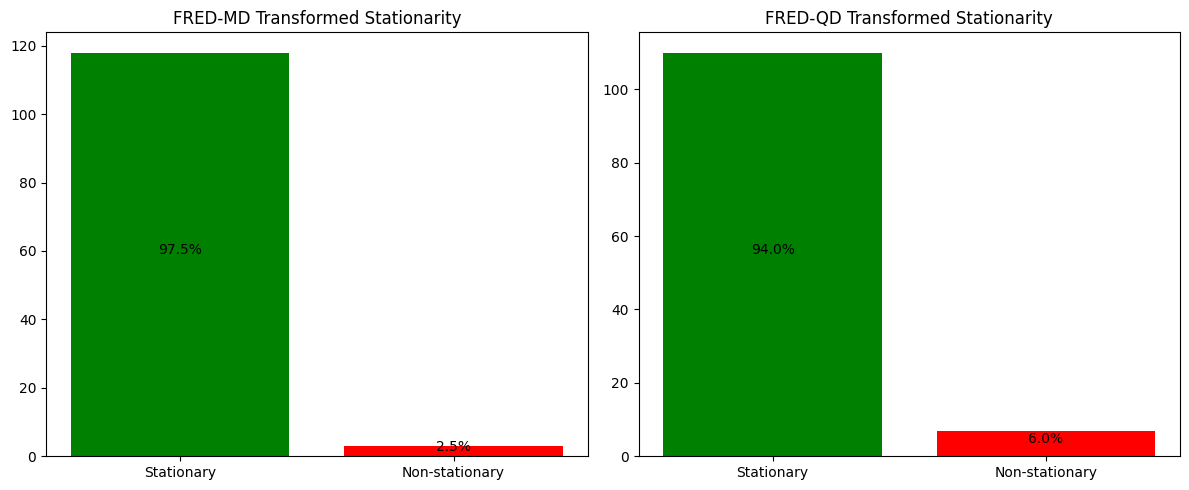


Examples of non-stationary features in transformed FRED-MD:
  - HOUSTNE (p-value: 0.2005)
  - HOUSTMW (p-value: 0.1719)
  - PERMITMW (p-value: 0.1023)

Examples of non-stationary features in transformed FRED-QD:
  - CES9092000001 (p-value: 0.1152)
  - HWIx (p-value: 0.4867)
  - CES2000000008x (p-value: 0.0611)
  - TLBSHNOx (p-value: 0.1148)
  - NWPIx (p-value: 0.9748)
  - TLBSNNCBBDIx (p-value: 0.0751)
  - TLBSNNBBDIx (p-value: 0.2048)


In [8]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Load the cleaned transformed datasets
fred_md_cleaned_transformed = pd.read_csv("FRED_md_cleaned_transformed.csv", index_col=0, parse_dates=True)
fred_qd_cleaned_transformed = pd.read_csv("FRED_qd_cleaned_transformed.csv", index_col=0, parse_dates=True)

# Function to perform ADF test on each feature
def check_stationarity(dataframe, significance_level=0.05):
    results = {}
    non_stationary_count = 0
    non_stationary_features = []
    
    for column in dataframe.columns:
        try:
            # Perform ADF test
            adf_result = adfuller(dataframe[column].dropna())
            p_value = adf_result[1]
            
            # Check if non-stationary
            is_stationary = p_value < significance_level
            results[column] = {
                'p_value': p_value,
                'is_stationary': is_stationary
            }
            
            if not is_stationary:
                non_stationary_count += 1
                non_stationary_features.append(column)
                
        except Exception as e:
            print(f"Error testing column {column}: {e}")
    
    non_stationary_percentage = (non_stationary_count / len(dataframe.columns)) * 100
    return results, non_stationary_count, non_stationary_percentage, non_stationary_features

# Perform ADF tests on both transformed datasets
print("Running ADF tests on transformed FRED-MD dataset...")
md_results, md_non_stationary_count, md_non_stationary_percentage, md_non_stationary_features = check_stationarity(fred_md_cleaned_transformed)

print("Running ADF tests on transformed FRED-QD dataset...")
qd_results, qd_non_stationary_count, qd_non_stationary_percentage, qd_non_stationary_features = check_stationarity(fred_qd_cleaned_transformed)

# Display results
print(f"\nFRED-MD Transformed Results:")
print(f"Total features: {len(fred_md_cleaned_transformed.columns)}")
print(f"Non-stationary features: {md_non_stationary_count}")
print(f"Percentage non-stationary: {md_non_stationary_percentage:.2f}%")

print(f"\nFRED-QD Transformed Results:")
print(f"Total features: {len(fred_qd_cleaned_transformed.columns)}")
print(f"Non-stationary features: {qd_non_stationary_count}")
print(f"Percentage non-stationary: {qd_non_stationary_percentage:.2f}%")

# Plot the results
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# MD dataset
ax[0].bar(['Stationary', 'Non-stationary'], 
          [len(fred_md_cleaned_transformed.columns) - md_non_stationary_count, md_non_stationary_count],
          color=['green', 'red'])
ax[0].set_title('FRED-MD Transformed Stationarity')
ax[0].text(0, (len(fred_md_cleaned_transformed.columns) - md_non_stationary_count)/2, 
           f"{100 - md_non_stationary_percentage:.1f}%", 
           ha='center')
ax[0].text(1, md_non_stationary_count/2, 
           f"{md_non_stationary_percentage:.1f}%", 
           ha='center')

# QD dataset
ax[1].bar(['Stationary', 'Non-stationary'], 
          [len(fred_qd_cleaned_transformed.columns) - qd_non_stationary_count, qd_non_stationary_count],
          color=['green', 'red'])
ax[1].set_title('FRED-QD Transformed Stationarity')
ax[1].text(0, (len(fred_qd_cleaned_transformed.columns) - qd_non_stationary_count)/2, 
           f"{100 - qd_non_stationary_percentage:.1f}%", 
           ha='center')
ax[1].text(1, qd_non_stationary_count/2, 
           f"{qd_non_stationary_percentage:.1f}%", 
           ha='center')

plt.tight_layout()
plt.show()

# List a few examples of non-stationary features from each dataset
print("\nExamples of non-stationary features in transformed FRED-MD:")
for col in md_non_stationary_features[:10]:  # First 10 non-stationary features
    print(f"  - {col} (p-value: {md_results[col]['p_value']:.4f})")

print("\nExamples of non-stationary features in transformed FRED-QD:")
for col in qd_non_stationary_features[:10]:  # First 10 non-stationary features
    print(f"  - {col} (p-value: {qd_results[col]['p_value']:.4f})")

In [11]:
# Create a DataFrame with the non-stationary features
# Extract the non-stationary features from the original DataFrames
non_stationary_features_md = fred_md_cleaned_transformed[md_non_stationary_features]
non_stationary_features_qd = fred_qd_cleaned_transformed[qd_non_stationary_features]

# Concatenate them side by side
non_stationary_df = pd.concat([non_stationary_features_md, non_stationary_features_qd], axis=1)

# Difference the non-stationary features
differenced_data = non_stationary_df.diff().dropna()

# Function to perform ADF test on differenced features
def check_stationarity_after_differencing(dataframe, significance_level=0.05):
    results = {}
    stationary_count = 0
    
    for column in dataframe.columns:
        try:
            # Perform ADF test
            adf_result = adfuller(dataframe[column].dropna())
            p_value = adf_result[1]
            
            # Check if stationary
            is_stationary = p_value < significance_level
            results[column] = {
                'p_value': p_value,
                'is_stationary': is_stationary
            }
            
            if is_stationary:
                stationary_count += 1
                
        except Exception as e:
            print(f"Error testing column {column}: {e}")
    
    stationary_percentage = (stationary_count / len(dataframe.columns)) * 100
    return results, stationary_count, stationary_percentage

# Run ADF test on differenced data
differenced_results, stationary_count, stationary_percentage = check_stationarity_after_differencing(differenced_data)

# Display results
print(f"Total features: {len(differenced_data.columns)}")
print(f"Stationary features after differencing: {stationary_count}")
print(f"Percentage stationary: {stationary_percentage:.2f}%")

# List a few examples of stationary features after differencing
print("\nExamples of stationary features after differencing:")
stationary_features = [col for col, res in differenced_results.items() if res['is_stationary']]
for col in stationary_features[:5]:
    print(f"  - {col} (p-value: {differenced_results[col]['p_value']:.4f})")

Error testing column HOUSTNE: zero-size array to reduction operation maximum which has no identity
Error testing column HOUSTMW: zero-size array to reduction operation maximum which has no identity
Error testing column PERMITMW: zero-size array to reduction operation maximum which has no identity
Error testing column CES9092000001: zero-size array to reduction operation maximum which has no identity
Error testing column HWIx: zero-size array to reduction operation maximum which has no identity
Error testing column CES2000000008x: zero-size array to reduction operation maximum which has no identity
Error testing column TLBSHNOx: zero-size array to reduction operation maximum which has no identity
Error testing column NWPIx: zero-size array to reduction operation maximum which has no identity
Error testing column TLBSNNCBBDIx: zero-size array to reduction operation maximum which has no identity
Error testing column TLBSNNBBDIx: zero-size array to reduction operation maximum which has no 

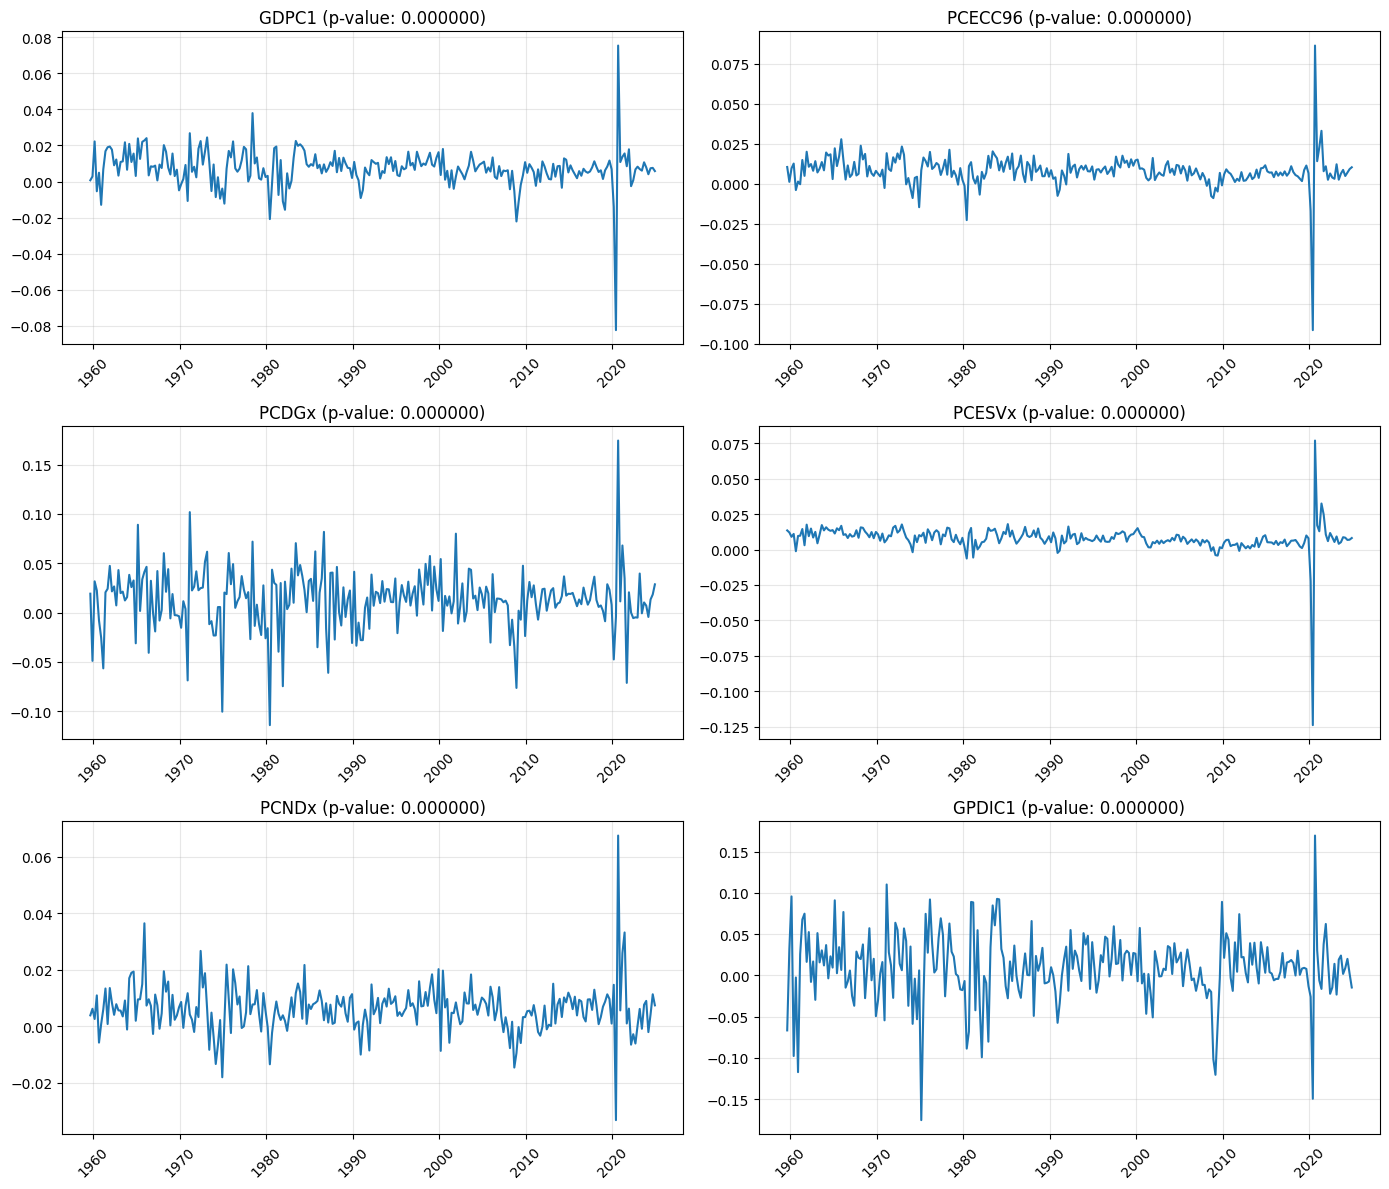

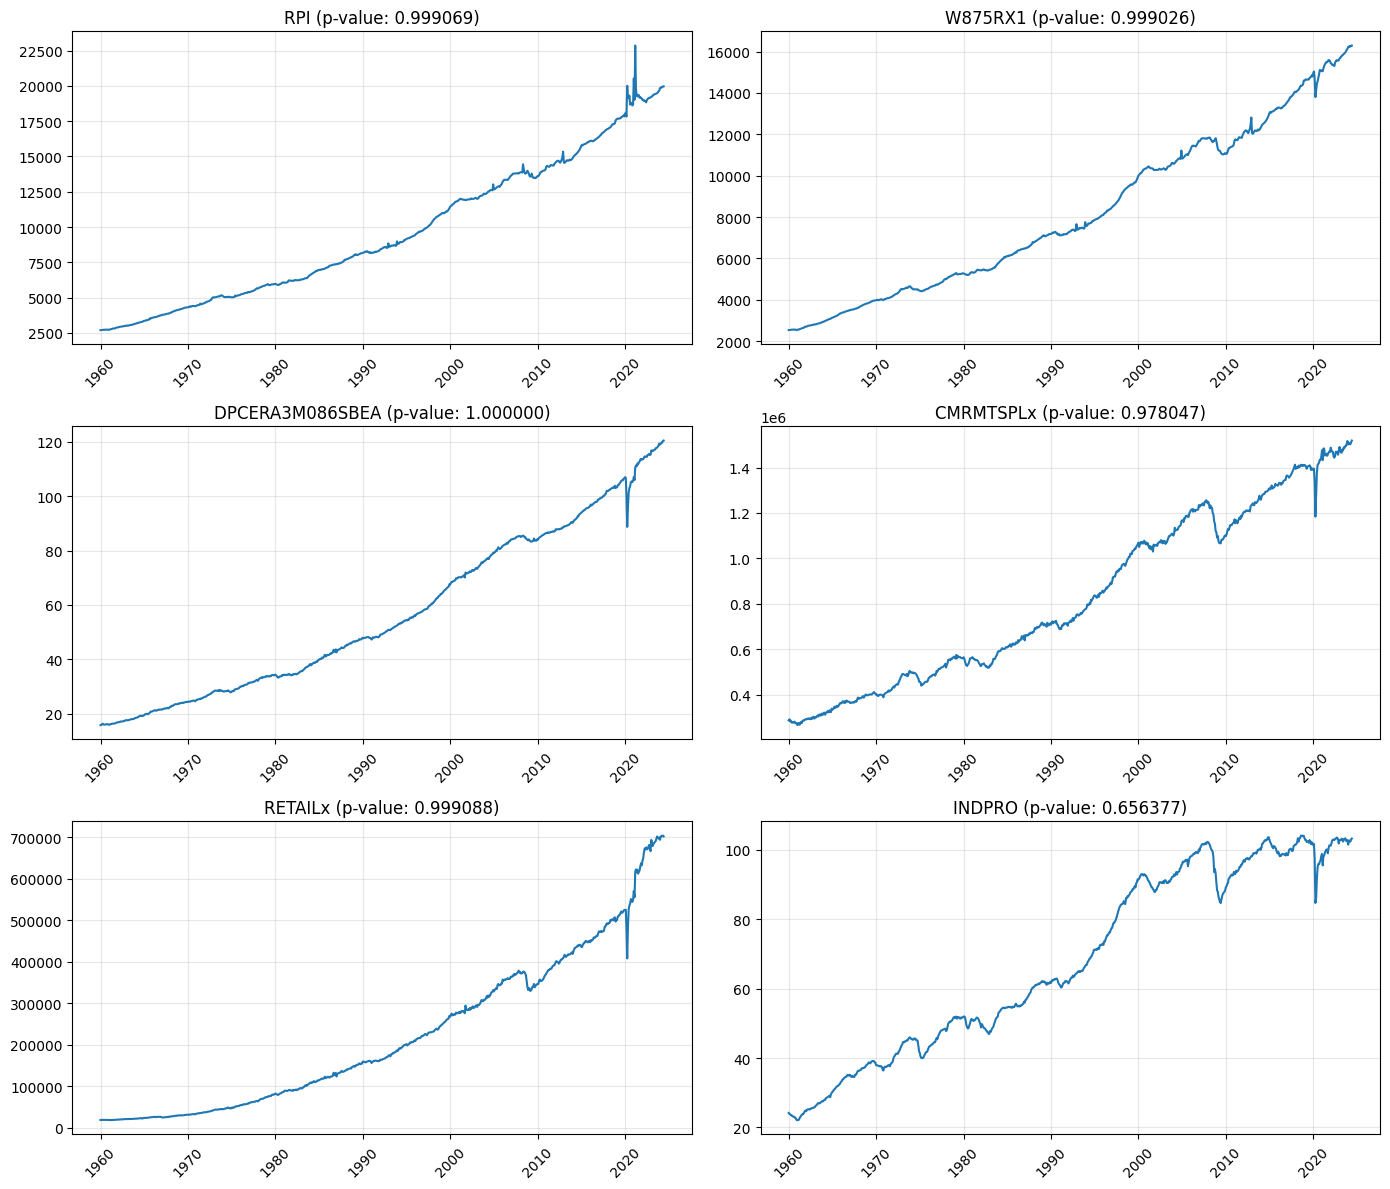

Top 10 Non-Stationary Features from FRED MD dataset:
RPI             p-value: 0.999069
W875RX1         p-value: 0.999026
DPCERA3M086SBEA p-value: 1.000000
CMRMTSPLx       p-value: 0.978047
RETAILx         p-value: 0.999088
INDPRO          p-value: 0.656377
IPFPNSS         p-value: 0.499763
IPFINAL         p-value: 0.509642
IPCONGD         p-value: 0.187231
IPDCONGD        p-value: 0.721346


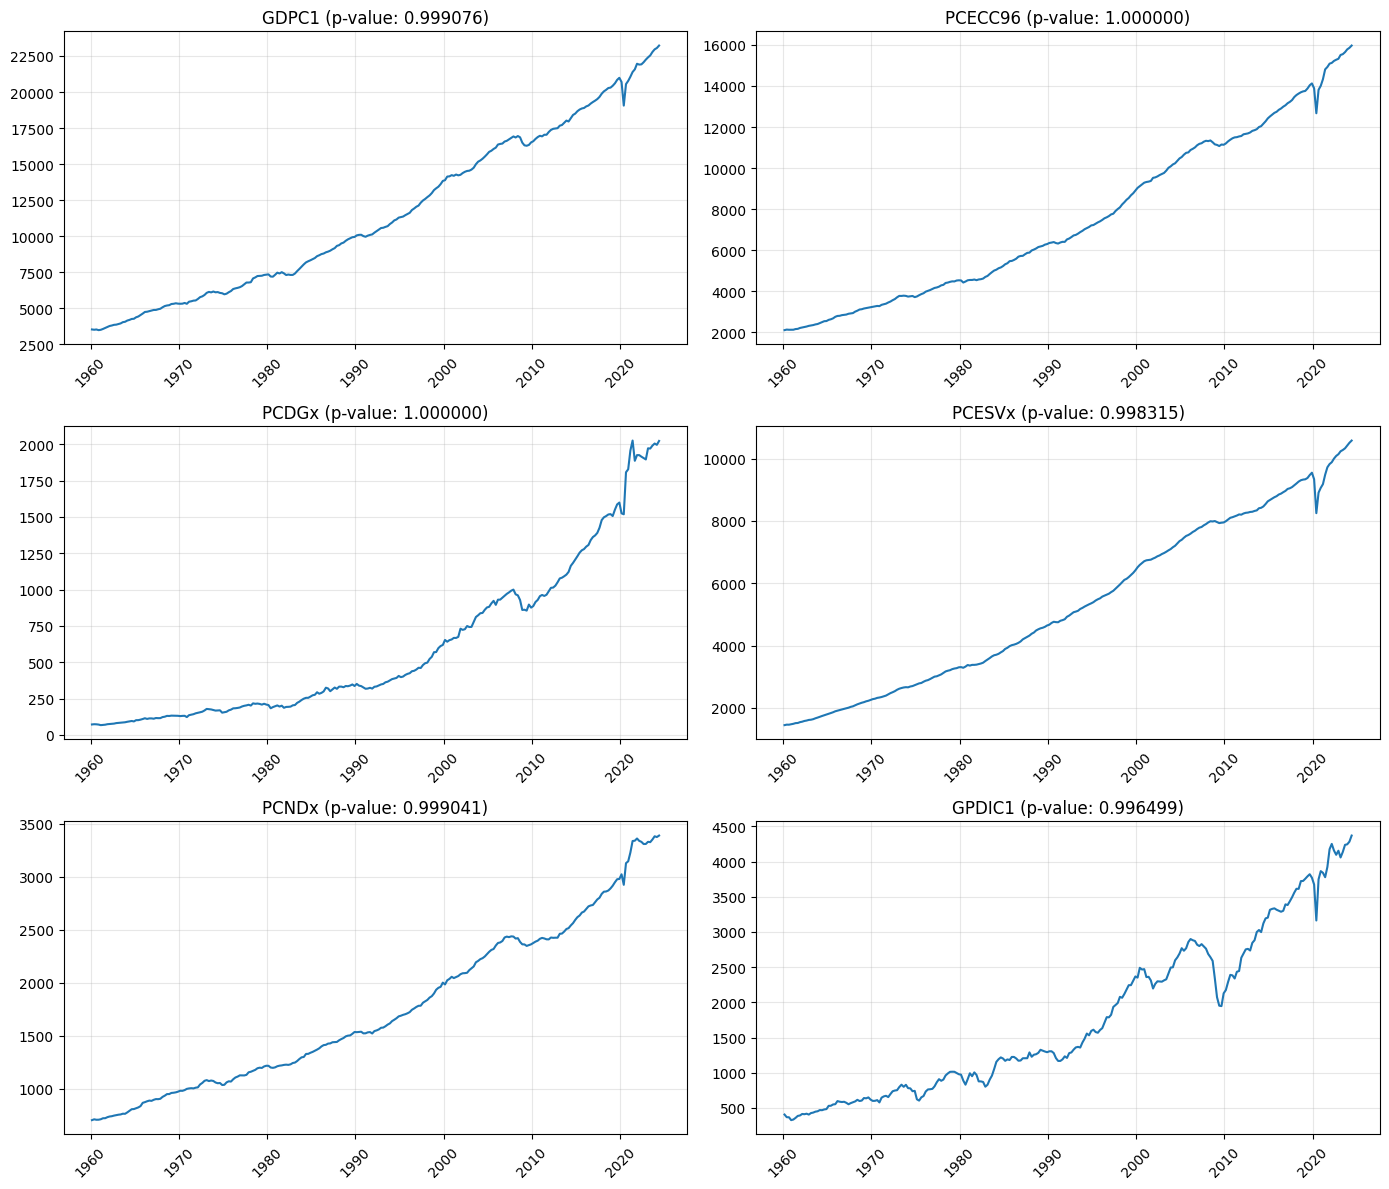


Top 10 Non-Stationary Features from FRED QD dataset:
GDPC1           p-value: 0.999076
PCECC96         p-value: 1.000000
PCDGx           p-value: 1.000000
PCESVx          p-value: 0.998315
PCNDx           p-value: 0.999041
GPDIC1          p-value: 0.996499
FPIx            p-value: 0.995941
Y033RC1Q027SBEAx p-value: 0.994281
PNFIx           p-value: 0.999078
PRFIx           p-value: 0.472863


In [7]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the transformed datasets
fred_md_transformed = pd.read_csv("fred_md_transformed.csv", index_col=0, parse_dates=True).iloc[1:]
fred_qd_transformed = pd.read_csv("fred_qd_transformed.csv", index_col=0, parse_dates=True).iloc[2:]

# Remove overlapping columns from fred_qd_transformed
overlapping_columns = set(fred_md_transformed.columns).intersection(set(fred_qd_transformed.columns))
fred_qd_transformed = fred_qd_transformed.drop(columns=overlapping_columns)

# Plot a selection of non-stationary features from the transformed datasets
# Using the same features shown in the image
features_to_plot_qd = ['GDPC1', 'PCECC96', 'PCDGx', 'PCESVx', 'PCNDx', 'GPDIC1']

# Set up the figure
fig, axs = plt.subplots(3, 2, figsize=(14, 12))
axs = axs.flatten()

# Plot each selected feature
for i, feature in enumerate(features_to_plot_qd):
    # Check if the feature is in the transformed dataset
    if feature in fred_qd_transformed.columns:
        # Perform ADF test on transformed data
        adf_result = adfuller(fred_qd_transformed[feature].dropna())
        p_value = adf_result[1]
        
        # Plot the time series
        axs[i].plot(fred_qd_transformed.index, fred_qd_transformed[feature])
        
        # Add title with feature name and p-value
        axs[i].set_title(f"{feature} (p-value: {p_value:.6f})")
        
        # Format the plot
        axs[i].grid(True, alpha=0.3)
        axs[i].tick_params(axis='x', rotation=45)
    else:
        print(f"Feature {feature} not found in transformed dataset")

# Adjust layout
plt.tight_layout()
plt.show()

# Create subplots for a selection of non-stationary features
import matplotlib.pyplot as plt

# Select a subset of non-stationary features to visualize (e.g., top 6)
features_to_plot = non_stationary_md[:6]  # First 6 non-stationary features from MD dataset

# Set up the figure
fig, axs = plt.subplots(3, 2, figsize=(14, 12))
axs = axs.flatten()

# Plot each selected feature
for i, feature in enumerate(features_to_plot):
    # Get the p-value from the test results
    p_value = md_results[feature]['p_value']
    
    # Plot the time series
    axs[i].plot(fred_md_cleaned.index, fred_md_cleaned[feature])
    
    # Add title with feature name and p-value
    axs[i].set_title(f"{feature} (p-value: {p_value:.6f})")
    
    # Format the plot
    axs[i].grid(True, alpha=0.3)
    axs[i].tick_params(axis='x', rotation=45)
    
# Adjust layout
plt.tight_layout()
plt.show()

# Create a table of non-stationary features with their p-values
non_stationary_data = []

# Get p-values for non-stationary features
for feature in non_stationary_md[:10]:  # Showing top 10 for brevity
    p_value = md_results[feature]['p_value']
    non_stationary_data.append((feature, p_value))

# Print the table
print("Top 10 Non-Stationary Features from FRED MD dataset:")
for feature, p_value in non_stationary_data:
    print(f"{feature:<15} p-value: {p_value:.6f}")

# Do the same for QD dataset
features_to_plot_qd = non_stationary_qd[:6]  # First 6 non-stationary features from QD dataset

# Set up the figure for QD features
fig, axs = plt.subplots(3, 2, figsize=(14, 12))
axs = axs.flatten()

# Plot each selected feature
for i, feature in enumerate(features_to_plot_qd):
    # Get the p-value from the test results
    p_value = qd_results[feature]['p_value']
    
    # Plot the time series
    axs[i].plot(fred_qd_cleaned.index, fred_qd_cleaned[feature])
    
    # Add title with feature name and p-value
    axs[i].set_title(f"{feature} (p-value: {p_value:.6f})")
    
    # Format the plot
    axs[i].grid(True, alpha=0.3)
    axs[i].tick_params(axis='x', rotation=45)
    
# Adjust layout
plt.tight_layout()
plt.show()

# Create a table of non-stationary features with their p-values for QD
non_stationary_data_qd = []

# Get p-values for non-stationary features
for feature in non_stationary_qd[:10]:  # Showing top 10 for brevity
    p_value = qd_results[feature]['p_value']
    non_stationary_data_qd.append((feature, p_value))

# Print the table
print("\nTop 10 Non-Stationary Features from FRED QD dataset:")
for feature, p_value in non_stationary_data_qd:
    print(f"{feature:<15} p-value: {p_value:.6f}")

            PCEPILFE     PCNDx  DMOTRG3Q086SBEA   HOUST5F  A014RE1Q156NBEA  \
date                                                                         
1960-03-01 -0.002554  0.002522        -0.007212 -0.009302              2.1   
1960-06-01  0.000619  0.010875         0.001537 -0.004013              0.6   
1960-09-01  0.000136 -0.005851        -0.002235 -0.014855              0.8   
1960-12-01 -0.000646  0.000684         0.003960  0.137096             -1.1   
1961-03-01 -0.001568  0.005939         0.005546  0.085230             -0.5   

            GS10TB3Mx   WPU0561  TLBSHNOx  LNS14000025     GCEC1  
date                                                              
1960-03-01       0.61 -0.003162  0.001358      -0.4333 -0.017163  
1960-06-01       1.27 -0.003780  0.028722       0.0333  0.011197  
1960-09-01       1.47 -0.003912  0.017184       0.4333  0.024183  
1960-12-01       1.58 -0.003272  0.021470       0.6000  0.006924  
1961-03-01       1.44 -0.001706  0.001699       0.4

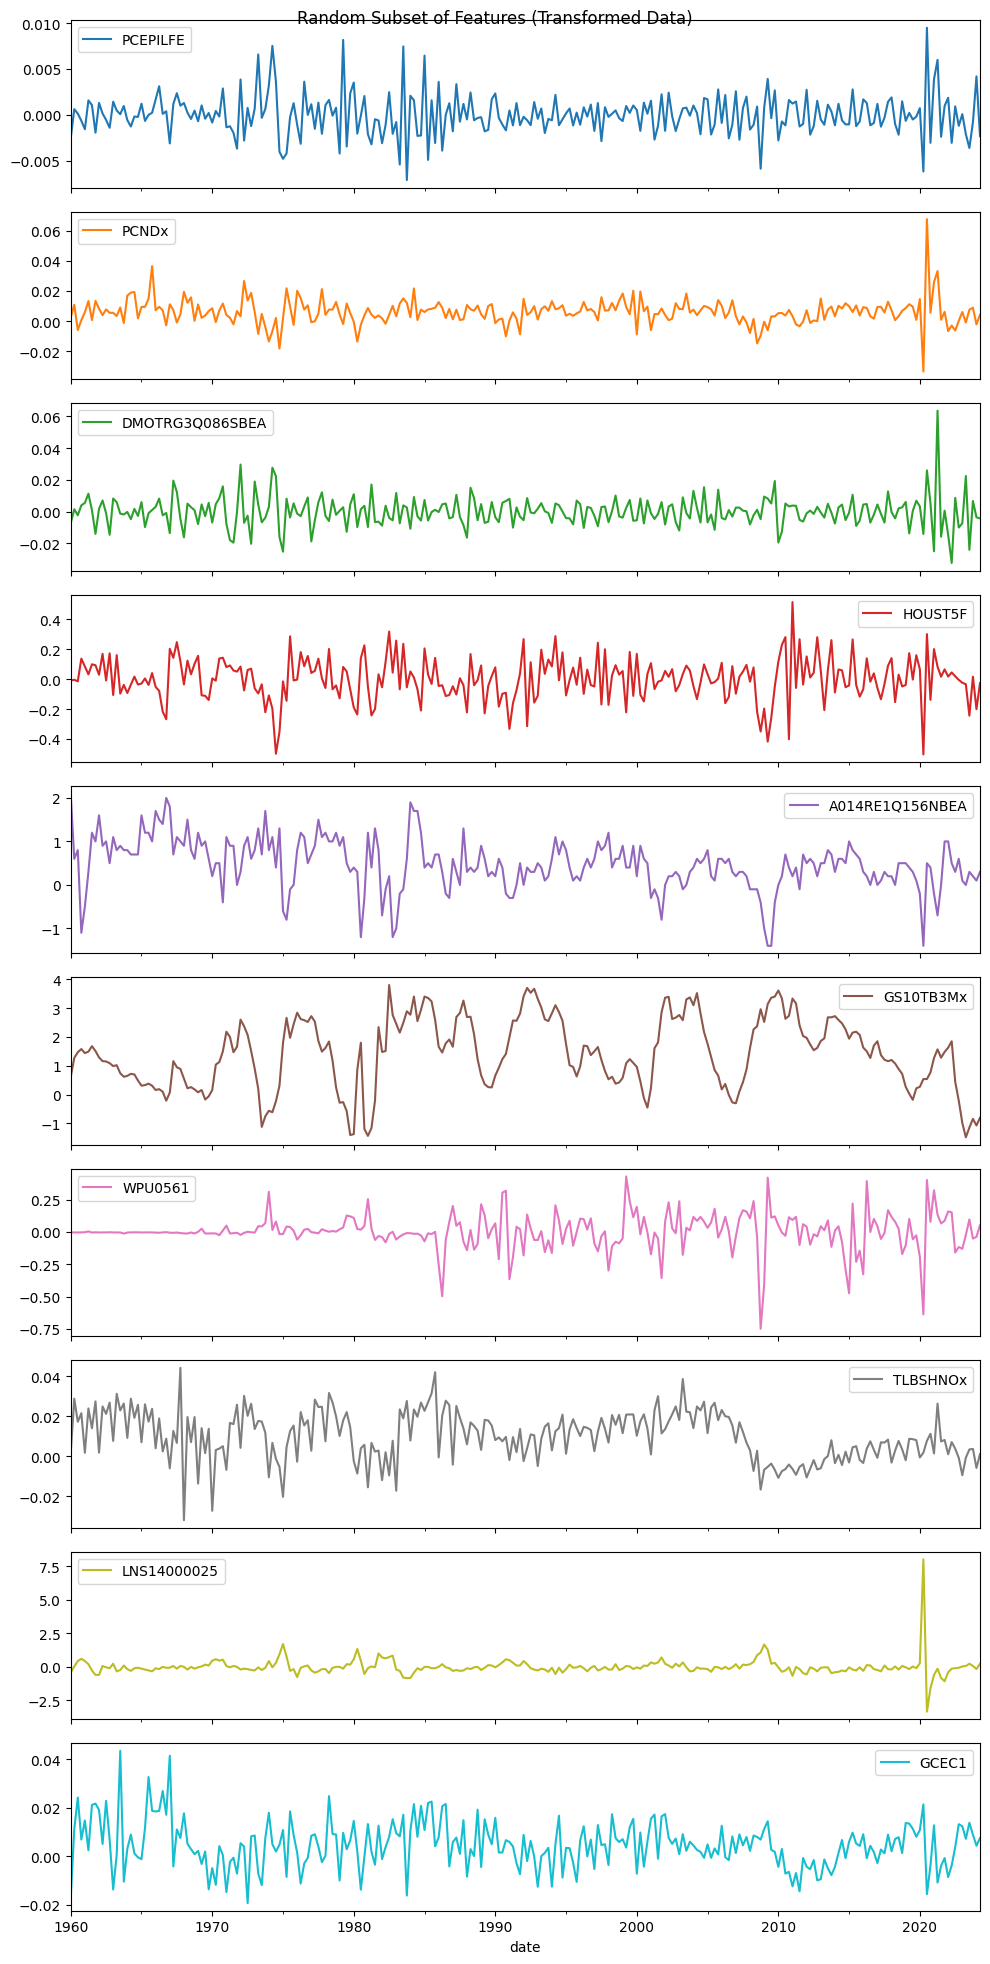

In [152]:
# Display a random subset of features (e.g., 10 features) from the transformed cleaned dataset
random_features_transformed = fred_qd_cleaned_transformed[list(random_features.columns)]
print(random_features_transformed.head())

# Plot the random subset of features
random_features_transformed.plot(subplots=True, figsize=(10, 20), title="Random Subset of Features (Transformed Data)")
plt.tight_layout()
plt.show()


How many outliers are there in GDP? 

In [108]:
import numpy as np

# Load the transformed datasets
Fred_qd_transformed = pd.read_csv("Fred_qd_transformed.csv", index_col=0, parse_dates=True, date_format="%m/%d/%Y")

Fred_qd_transformed = Fred_qd_transformed.iloc[1:]

# Extract the GDPC1 feature from the transformed dataset
gdpc1_series = Fred_qd_transformed['GDPC1']

# Calculate the median of the series
median_gdpc1 = np.median(gdpc1_series.dropna())

# Calculate the interquartile range (IQR)
q1 = np.percentile(gdpc1_series.dropna(), 25)
q3 = np.percentile(gdpc1_series.dropna(), 75)
iqr = q3 - q1

# Determine outliers (values outside 10 * IQR from the median)
outliers = np.abs(gdpc1_series - median_gdpc1) > (10 * iqr)

# Count the number of outliers
num_outliers = outliers.sum()

print(f"Number of outliers in GDPC1: {num_outliers}")

Number of outliers in GDPC1: 1


Number of outliers total for fred md and fred qd

In [63]:
outlier_date = outliers[outliers].index
print(f"Date of the outlier: {outlier_date}")

Date of the outlier: Index(['2020-06-01'], dtype='object', name='date')


In [65]:
# Load the transformed datasets
fred_md_transformed = pd.read_csv("fred_md_transformed.csv", index_col=0, parse_dates=True)
fred_qd = pd.read_csv("fred_qd_transformed.csv", index_col=0, parse_dates=True)

# Remove features from qd if they are also in qd
overlapping_columns = set(fred_md.columns).intersection(set(fred_qd.columns))

# Drop overlapping columns from fred_qd
fred_qd_transformed = fred_qd.drop(columns=overlapping_columns)

# Function to calculate outliers for each feature
def calculate_outliers(dataframe):
    outliers_count = {}
    for column in dataframe.columns:
        feature_series = dataframe[column].dropna()
        median = feature_series.median()
        iqr = feature_series.quantile(0.75) - feature_series.quantile(0.25)
        outliers = np.abs(feature_series - median) > (10 * iqr)
        outliers_count[column] = outliers.sum()
    return outliers_count

# Calculate outliers for both datasets
outliers_md = calculate_outliers(fred_md_transformed)
outliers_qd = calculate_outliers(fred_qd_transformed)

# Print the results
print("Number of outliers in each feature of fred_md_transformed:")
print(outliers_md)

print("\nNumber of outliers in each feature of fred_qd_transformed:")
print(outliers_qd)

Number of outliers in each feature of fred_md_transformed:
{'RPI': np.int64(7), 'W875RX1': np.int64(2), 'DPCERA3M086SBEA': np.int64(3), 'CMRMTSPLx': np.int64(1), 'RETAILx': np.int64(2), 'INDPRO': np.int64(1), 'IPFPNSS': np.int64(1), 'IPFINAL': np.int64(1), 'IPCONGD': np.int64(1), 'IPDCONGD': np.int64(2), 'IPNCONGD': np.int64(0), 'IPBUSEQ': np.int64(1), 'IPMAT': np.int64(1), 'IPDMAT': np.int64(2), 'IPNMAT': np.int64(0), 'IPMANSICS': np.int64(1), 'IPB51222S': np.int64(0), 'IPFUELS': np.int64(0), 'CUMFNS': np.int64(1), 'HWI': np.int64(0), 'HWIURATIO': np.int64(1), 'CLF16OV': np.int64(1), 'CE16OV': np.int64(2), 'UNRATE': np.int64(2), 'UEMPMEAN': np.int64(1), 'UEMPLT5': np.int64(2), 'UEMP5TO14': np.int64(3), 'UEMP15OV': np.int64(1), 'UEMP15T26': np.int64(1), 'UEMP27OV': np.int64(0), 'CLAIMSx': np.int64(3), 'PAYEMS': np.int64(2), 'USGOOD': np.int64(1), 'CES1021000001': np.int64(6), 'USCONS': np.int64(1), 'MANEMP': np.int64(1), 'DMANEMP': np.int64(2), 'NDMANEMP': np.int64(1), 'SRVPRD': np.int

In [64]:
# Sort features by the number of outliers in descending order for FRED MD, excluding features with 0 outliers
sorted_outliers_md = [(feature, count) for feature, count in sorted_outliers_md if count > 0]

# Sort features by the number of outliers in descending order for FRED QD, excluding features with 0 outliers
sorted_outliers_qd = [(feature, count) for feature, count in sorted_outliers_qd if count > 0]

# Display the sorted features and their outlier counts for FRED MD
print("Features with the most outliers in FRED MD (sorted from highest to lowest):")
for feature, count in sorted_outliers_md:
    print(f"{feature}: {count}")

# Display the sorted features and their outlier counts for FRED QD
print("\nFeatures with the most outliers in FRED QD (sorted from highest to lowest):")
for feature, count in sorted_outliers_qd:
    print(f"{feature}: {count}")

Features with the most outliers in FRED MD (sorted from highest to lowest):
NONBORRES: 14
FEDFUNDS: 8
DTCOLNVHFNM: 8
RPI: 7
CP3Mx: 7
TB3MS: 7
CES1021000001: 6
NONREVSL: 6
DTCTHFNM: 6
CONSPI: 5
TB6MS: 4
DPCERA3M086SBEA: 3
UEMP5TO14: 3
CLAIMSx: 3
M1SL: 3
TOTRESNS: 3
BUSLOANS: 3
REALLN: 3
OILPRICEx: 3
W875RX1: 2
RETAILx: 2
IPDCONGD: 2
IPDMAT: 2
CE16OV: 2
UNRATE: 2
UEMPLT5: 2
PAYEMS: 2
DMANEMP: 2
SRVPRD: 2
USTPU: 2
USTRADE: 2
USGOVT: 2
M2SL: 2
GS1: 2
CMRMTSPLx: 1
INDPRO: 1
IPFPNSS: 1
IPFINAL: 1
IPCONGD: 1
IPBUSEQ: 1
IPMAT: 1
IPMANSICS: 1
CUMFNS: 1
HWIURATIO: 1
CLF16OV: 1
UEMPMEAN: 1
UEMP15OV: 1
UEMP15T26: 1
USGOOD: 1
USCONS: 1
MANEMP: 1
NDMANEMP: 1
USWTRADE: 1
USFIRE: 1
BUSINVx: 1
ISRATIOx: 1
M2REAL: 1
BOGMBASE: 1
CUSR0000SAS: 1

Features with the most outliers in FRED QD (sorted from highest to lowest):
NONBORRES: 8
DPIC96: 3
UNRATESTx: 3
TOTRESNS: 3
CLAIMSx: 3
PCECC96: 2
PCESVx: 2
IPDCONGD: 2
USLAH: 2
USSERV: 2
CE16OV: 2
UNRATE: 2
LNS14000012: 2
LNS14000025: 2
LNS14000026: 2
UEMPLT5: 2
U

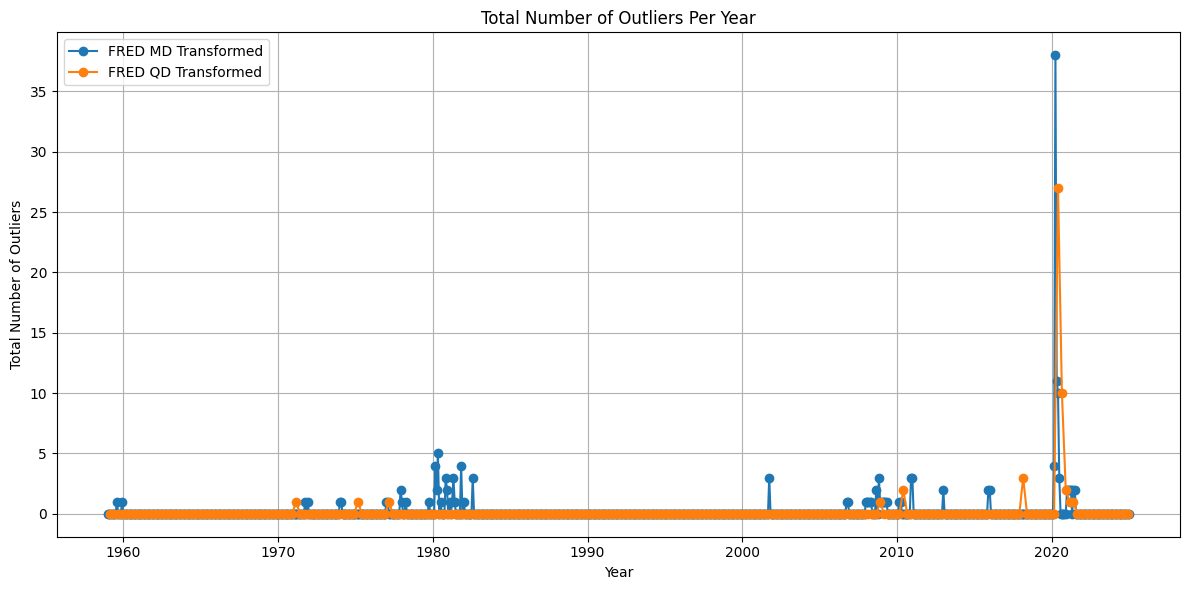

Dimensions of fred_md_transformed: (793, 126)
Dimensions of fred_qd_transformed: (264, 149)


In [41]:
# Function to calculate total outliers per year
def calculate_outliers_per_year(dataframe):
    outliers_per_quarter_or_month = {}
    for column in dataframe.columns:
        feature_series = dataframe[column].dropna()
        median = feature_series.median()
        iqr = feature_series.quantile(0.75) - feature_series.quantile(0.25)
        outliers = np.abs(feature_series - median) > (10 * iqr)
        for date, count in outliers.items():
            outliers_per_quarter_or_month[date] = outliers_per_quarter_or_month.get(date, 0) + count
    return outliers_per_quarter_or_month

# Calculate total outliers per year for both datasets
outliers_md_per_year = calculate_outliers_per_year(fred_md_transformed)
outliers_qd_per_year = calculate_outliers_per_year(fred_qd_transformed)

# Convert to sorted lists of years and counts
years_md, counts_md = zip(*sorted(outliers_md_per_year.items()))
years_qd, counts_qd = zip(*sorted(outliers_qd_per_year.items()))

# Plot the graphs
plt.figure(figsize=(12, 6))

# Plot for fred_md_transformed
plt.plot(years_md, counts_md, label='FRED MD Transformed', marker='o')

# Plot for fred_qd_transformed
plt.plot(years_qd, counts_qd, label='FRED QD Transformed', marker='o')

# Add labels, title, and legend
plt.xlabel('Year')
plt.ylabel('Total Number of Outliers')
plt.title('Total Number of Outliers Per Year')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

# Display the dimensions of the transformed datasets
print("Dimensions of fred_md_transformed:", fred_md_transformed.shape)
print("Dimensions of fred_qd_transformed:", fred_qd_transformed.shape)

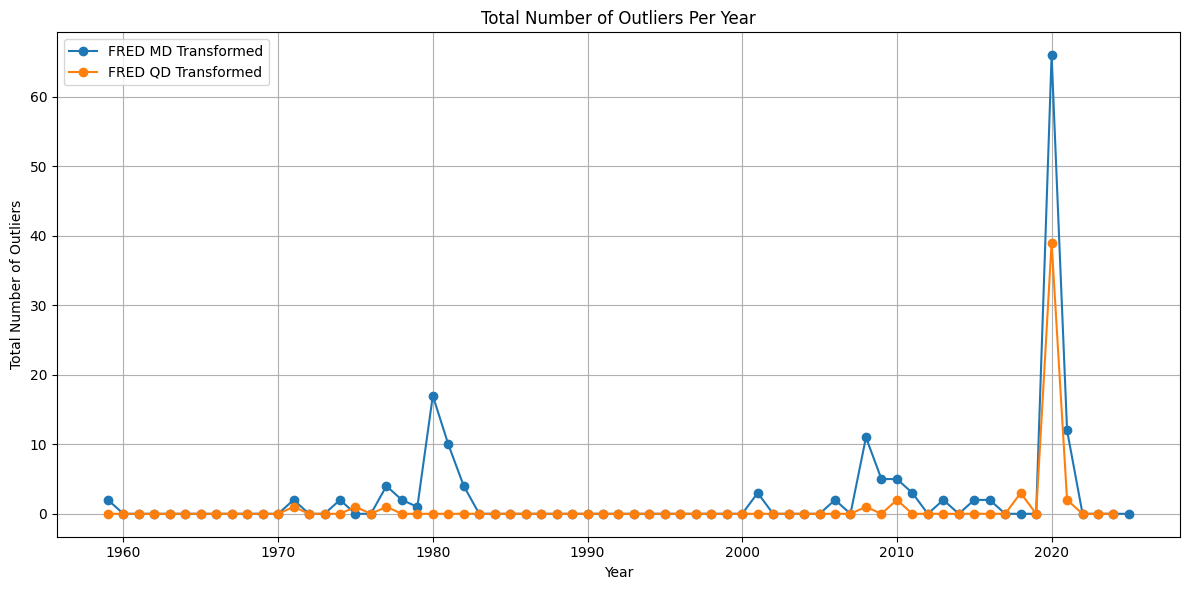

Dimensions of fred_md_transformed: (793, 126)
Dimensions of fred_qd_transformed: (264, 149)


In [42]:
# Function to calculate total outliers per year
def calculate_outliers_per_year(dataframe):
    outliers_per_quarter_or_month = {}
    for column in dataframe.columns:
        feature_series = dataframe[column].dropna()
        median = feature_series.median()
        iqr = feature_series.quantile(0.75) - feature_series.quantile(0.25)
        outliers = np.abs(feature_series - median) > (10 * iqr)
        yearly_outliers = outliers.groupby(outliers.index.year).sum()
        for date, count in yearly_outliers.items():
            outliers_per_quarter_or_month[date] = outliers_per_quarter_or_month.get(date, 0) + count
    return outliers_per_quarter_or_month

# Calculate total outliers per year for both datasets
outliers_md_per_year = calculate_outliers_per_year(fred_md_transformed)
outliers_qd_per_year = calculate_outliers_per_year(fred_qd_transformed)

# Convert to sorted lists of years and counts
years_md, counts_md = zip(*sorted(outliers_md_per_year.items()))
years_qd, counts_qd = zip(*sorted(outliers_qd_per_year.items()))

# Plot the graphs
plt.figure(figsize=(12, 6))

# Plot for fred_md_transformed
plt.plot(years_md, counts_md, label='FRED MD Transformed', marker='o')

# Plot for fred_qd_transformed
plt.plot(years_qd, counts_qd, label='FRED QD Transformed', marker='o')

# Add labels, title, and legend
plt.xlabel('Year')
plt.ylabel('Total Number of Outliers')
plt.title('Total Number of Outliers Per Year')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

# Display the dimensions of the transformed datasets
print("Dimensions of fred_md_transformed:", fred_md_transformed.shape)
print("Dimensions of fred_qd_transformed:", fred_qd_transformed.shape)

What is up with 1980?

In [35]:
# Filter features with outliers in 1980
features_with_outliers_1980 = [feature for feature, count in outliers_md.items() if count > 0 and 1980 in outliers_md_per_year]
print("Features from FRED MD with outliers in 1980:")
print(features_with_outliers_1980)

# Sort features by the number of outliers in descending order
sorted_outliers_md = sorted(outliers_md.items(), key=lambda x: x[1], reverse=True)

print("Features from FRED MD sorted by the number of outliers (highest to lowest):")
for feature, count in sorted_outliers_md:
    print(f"{feature}: {count}")

Features from FRED MD with outliers in 1980:
['RPI', 'W875RX1', 'DPCERA3M086SBEA', 'CMRMTSPLx', 'RETAILx', 'INDPRO', 'IPFPNSS', 'IPFINAL', 'IPCONGD', 'IPDCONGD', 'IPBUSEQ', 'IPMAT', 'IPDMAT', 'IPMANSICS', 'CUMFNS', 'HWIURATIO', 'CLF16OV', 'CE16OV', 'UNRATE', 'UEMPMEAN', 'UEMPLT5', 'UEMP5TO14', 'UEMP15OV', 'UEMP15T26', 'CLAIMSx', 'PAYEMS', 'USGOOD', 'CES1021000001', 'USCONS', 'MANEMP', 'DMANEMP', 'NDMANEMP', 'SRVPRD', 'USTPU', 'USWTRADE', 'USTRADE', 'USFIRE', 'USGOVT', 'BUSINVx', 'ISRATIOx', 'M1SL', 'M2SL', 'M2REAL', 'BOGMBASE', 'TOTRESNS', 'NONBORRES', 'BUSLOANS', 'REALLN', 'NONREVSL', 'CONSPI', 'FEDFUNDS', 'CP3Mx', 'TB3MS', 'TB6MS', 'GS1', 'OILPRICEx', 'CUSR0000SAS', 'DTCOLNVHFNM', 'DTCTHFNM']
Features from FRED MD sorted by the number of outliers (highest to lowest):
NONBORRES: 14
FEDFUNDS: 8
DTCOLNVHFNM: 8
RPI: 7
CP3Mx: 7
TB3MS: 7
CES1021000001: 6
NONREVSL: 6
DTCTHFNM: 6
CONSPI: 5
TB6MS: 4
DPCERA3M086SBEA: 3
UEMP5TO14: 3
CLAIMSx: 3
M1SL: 3
TOTRESNS: 3
BUSLOANS: 3
REALLN: 3
OILPRICEx

EDA: seasonality

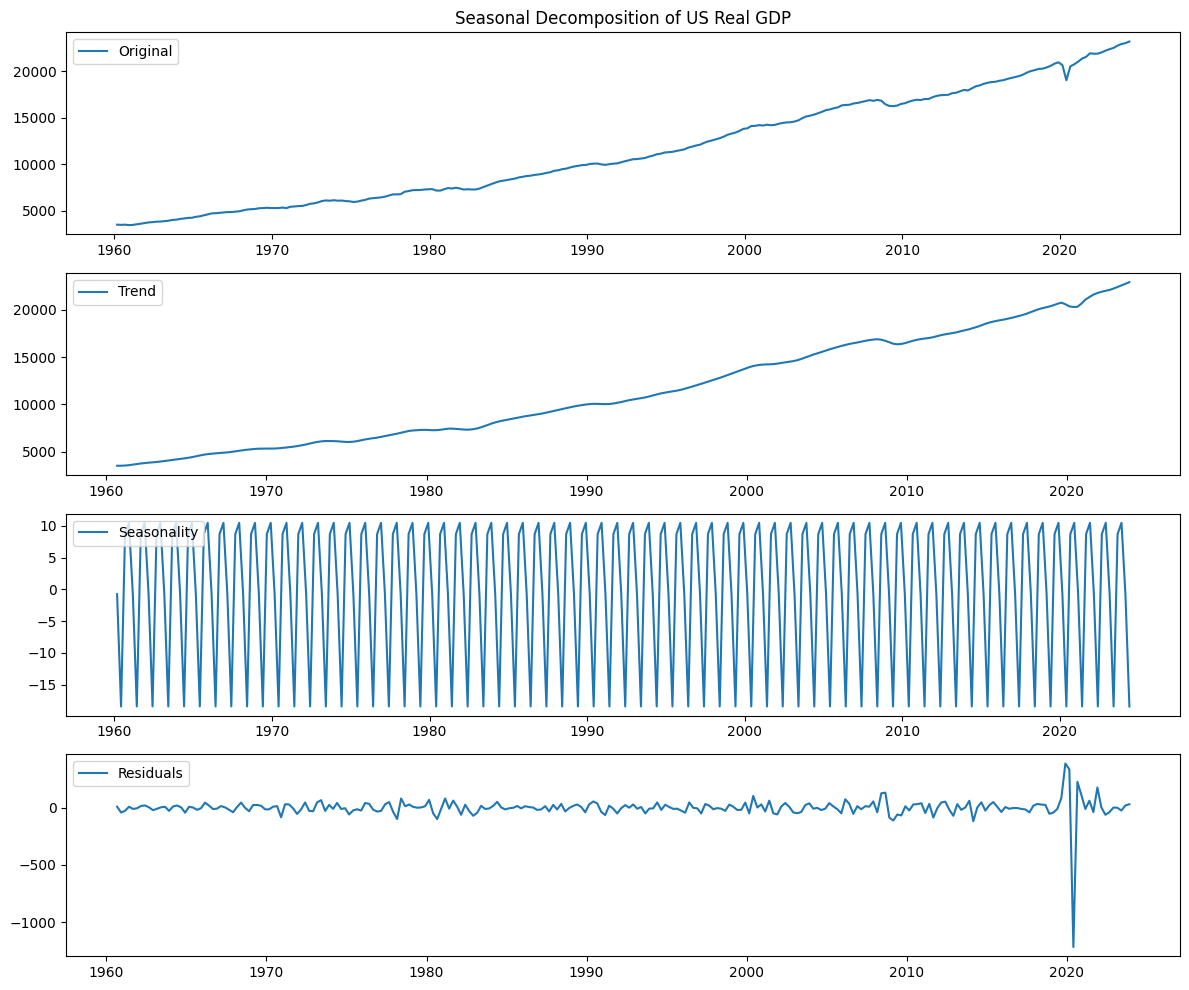

In [231]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Ensure GDP series is datetime-indexed
# Convert date column to datetime
qd_df = pd.read_csv("FRED_qd_cleaned.csv")
gdp_series = qd_df[['sasdate', 'GDPC1']].copy()
gdp_series['sasdate'] = pd.to_datetime(gdp_series['sasdate'])
gdp_series.set_index('sasdate', inplace=True)

# Perform seasonal decomposition (assume quarterly frequency: freq=4)
decomposition = seasonal_decompose(gdp_series['GDPC1'], model='additive', period=4)

# Plot the components: Original, Trend, Seasonal, Residual
plt.figure(figsize=(12, 10))

plt.subplot(411)
plt.plot(gdp_series['GDPC1'], label='Original')
plt.legend(loc='upper left')
plt.title('Seasonal Decomposition of US Real GDP')

plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


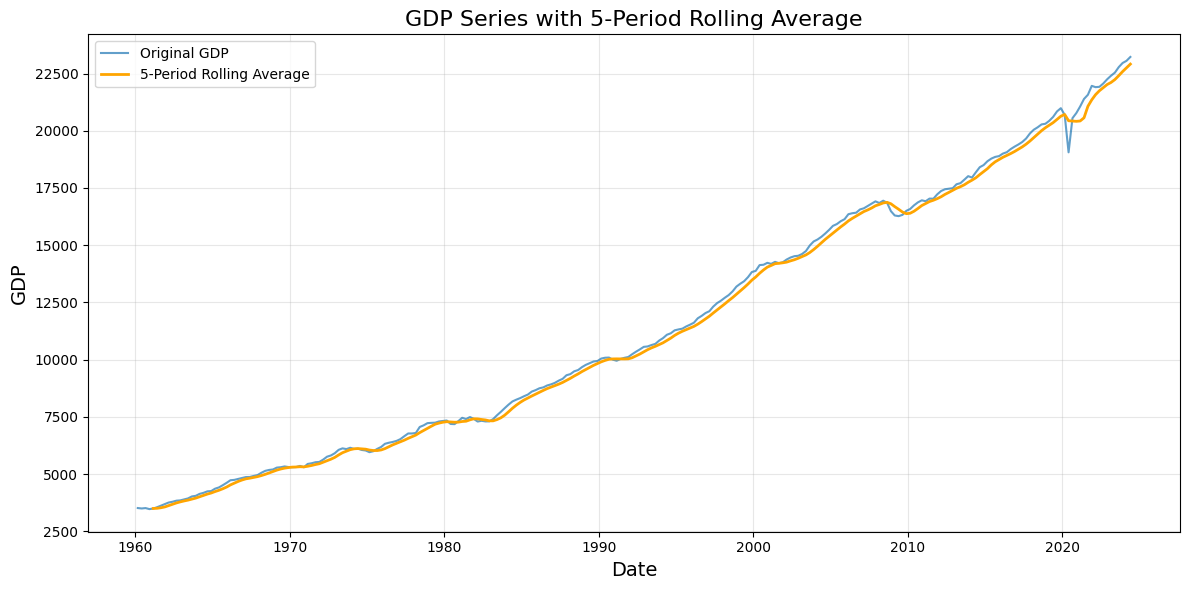

In [232]:
# Ensure GDP series is defined and has the required data
if not isinstance(gdp_series, pd.Series) and 'GDPC1' not in gdp_series.columns:
	raise ValueError("The 'GDPC1' column is missing in gdp_series.")

# If gdp_series is a Series, convert it to a DataFrame
if isinstance(gdp_series, pd.Series):
	gdp_series = gdp_series.to_frame(name='GDPC1')

# Calculate the 5-period rolling average if not already present
if 'Rolling_Avg' not in gdp_series.columns:
	gdp_series['Rolling_Avg'] = gdp_series['GDPC1'].rolling(window=5).mean()

# Plot the original GDP series and the rolling average
plt.figure(figsize=(12, 6))
plt.plot(gdp_series.index, gdp_series['GDPC1'], label='Original GDP', alpha=0.7)
plt.plot(gdp_series.index, gdp_series['Rolling_Avg'], label='5-Period Rolling Average', color='orange', linewidth=2)

# Add labels, title, and legend
plt.xlabel('Date', fontsize=14)
plt.ylabel('GDP', fontsize=14)
plt.title('GDP Series with 5-Period Rolling Average', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

EDA: GDP

Autocorrelation and autocovariance analysis 

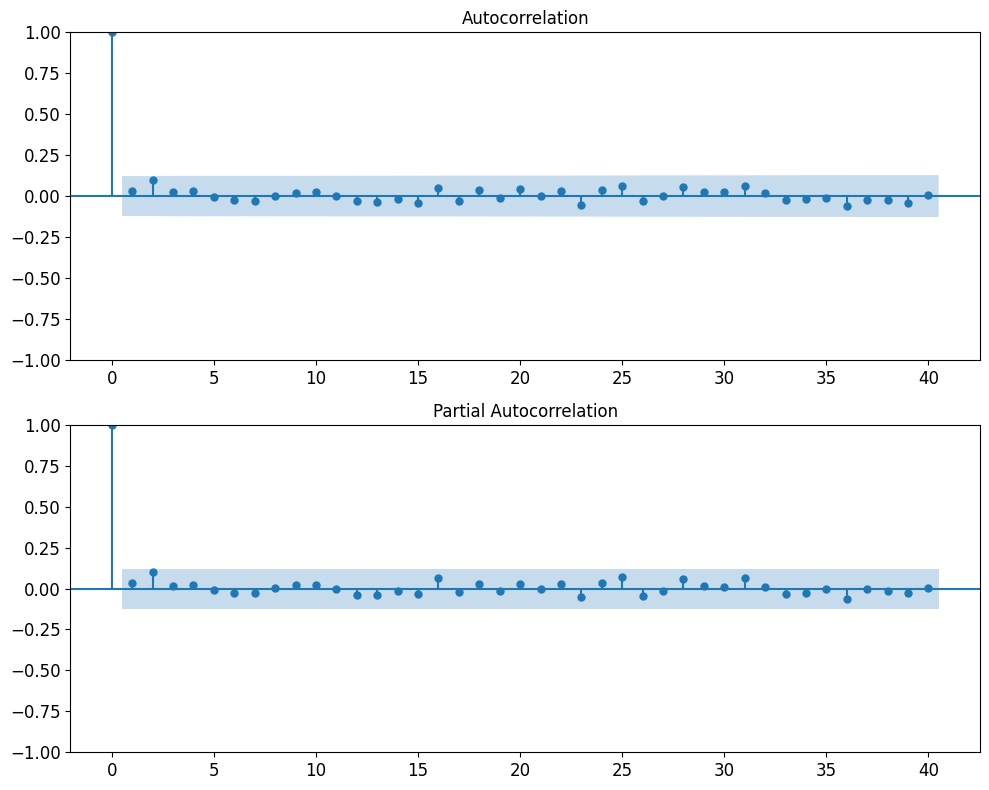

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot acf and pacf
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(fred_qd_cleaned_transformed['GDPC1'], ax=ax1, lags=40)
plot_pacf(fred_qd_cleaned_transformed['GDPC1'], ax=ax2, lags=40)

ax1.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()


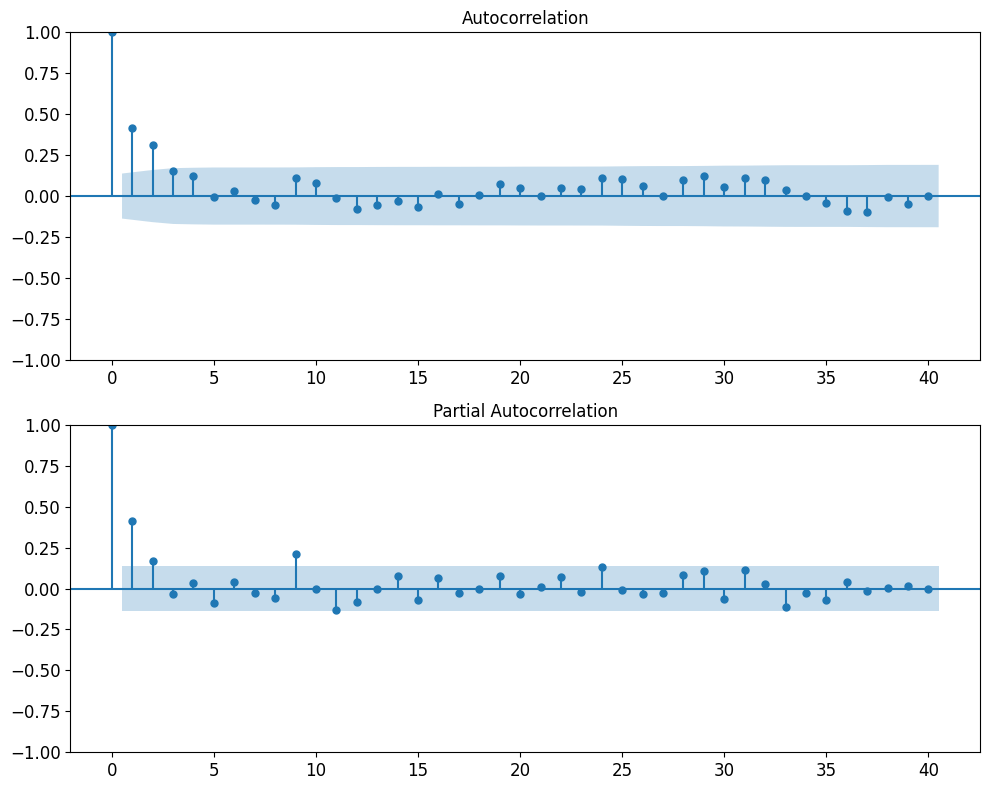

In [10]:
# Plot acf and pacf
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# only dif transformed
data_diff = pd.read_csv("FRED_qd_train.csv", index_col=0, parse_dates=True)

plot_acf(data_diff['GDPC1'], ax=ax1, lags=40)
plot_pacf(data_diff['GDPC1'], ax=ax2, lags=40)

ax1.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

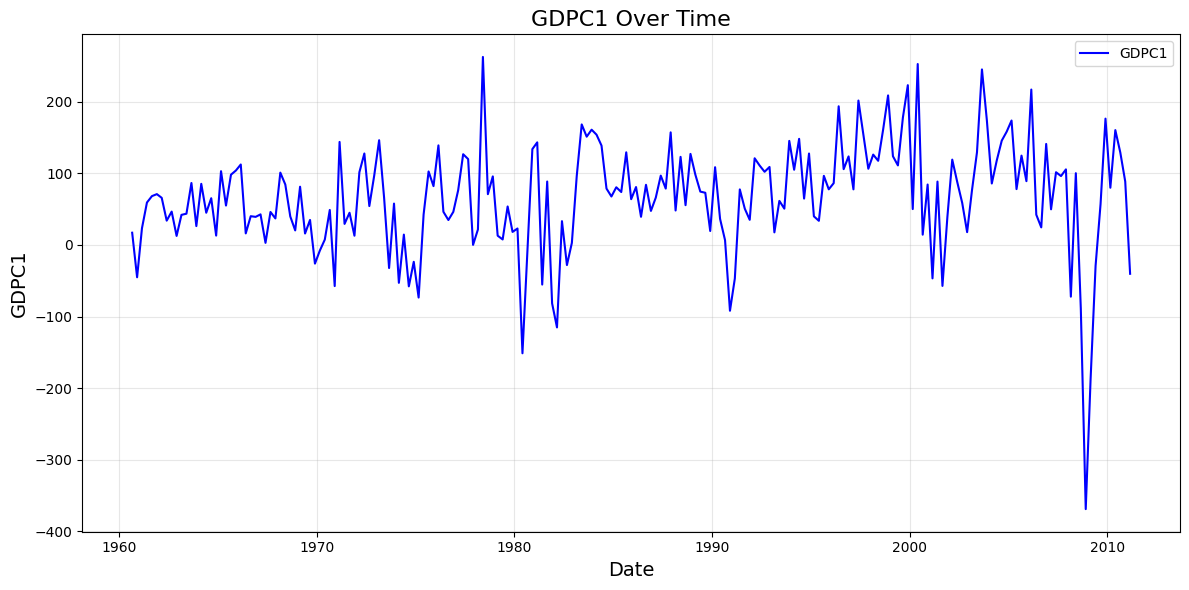

In [11]:
import matplotlib.pyplot as plt

# Plot the GDPC1 column
plt.figure(figsize=(12, 6))
plt.plot(data_diff.index, data_diff['GDPC1'], label='GDPC1', color='blue')

# Add labels, title, and legend
plt.xlabel('Date', fontsize=14)
plt.ylabel('GDPC1', fontsize=14)
plt.title('GDPC1 Over Time', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

for granger causality, variables need to be same frequency

In [4]:
# Define or load the monthly_aggregate_md DataFrame
# For demonstration purposes, we'll create a sample DataFrame. Replace this with your actual data loading logic.
import pandas as pd
import numpy as np
from feature_selection import combine_qd_and_md_as_qd

# Use the combine_qd_and_md_as_qd function to combine the datasets
combined_data = combine_qd_and_md_as_qd(fred_qd_cleaned_transformed, fred_md_cleaned_transformed)

# Ensure indices are datetime and have the same frequency
combined_data.index = pd.to_datetime(combined_data.index)


# Verify the result
print(f"Number of NaN values in the combined dataset: {combined_data.isnull().sum().sum()}")
print(f"Remaining rows in the dataset: {len(combined_data)}")


Number of NaN values in the combined dataset: 0
Remaining rows in the dataset: 258


In [222]:
# Calculate the correlation matrix
correlation_matrix = combined_data.corr()

# Take the absolute value of the correlation matrix
absolute_correlation_matrix = correlation_matrix.abs()

# Get the absolute correlation of all features with GDPC1
gdpc1_correlation = absolute_correlation_matrix['GDPC1'].sort_values(ascending=False)

# Display the top 10 features with the highest absolute correlation with GDPC1
print("Top 10 features with the highest absolute correlation with GDPC1:")
print(gdpc1_correlation.head(30))

Top 10 features with the highest absolute correlation with GDPC1:
GDPC1               1.000000
OUTBS               0.995806
OUTNFB              0.988203
HOANBS              0.826496
PCECC96             0.821935
HOABS               0.811627
USPRIV              0.789447
GPDIC1              0.787688
LNS14000025         0.782030
UNRATESTx           0.758712
LNS14000012         0.737200
LNS14000026         0.732188
PCESVx              0.723958
LNS12032194         0.712781
IPB51110SQ          0.704720
FPIx                0.701611
USPBS               0.694587
USSERV              0.691689
USLAH               0.684072
HWIURATIOx          0.677372
Y033RC1Q027SBEAx    0.642349
USEHS               0.634652
PNFIx               0.628966
PCNDx               0.622697
IMPGSC1             0.561898
PCDGx               0.554617
M1SL                0.500373
USINFO              0.488776
CES9093000001       0.485145
PRFIx               0.483593
Name: GDPC1, dtype: float64


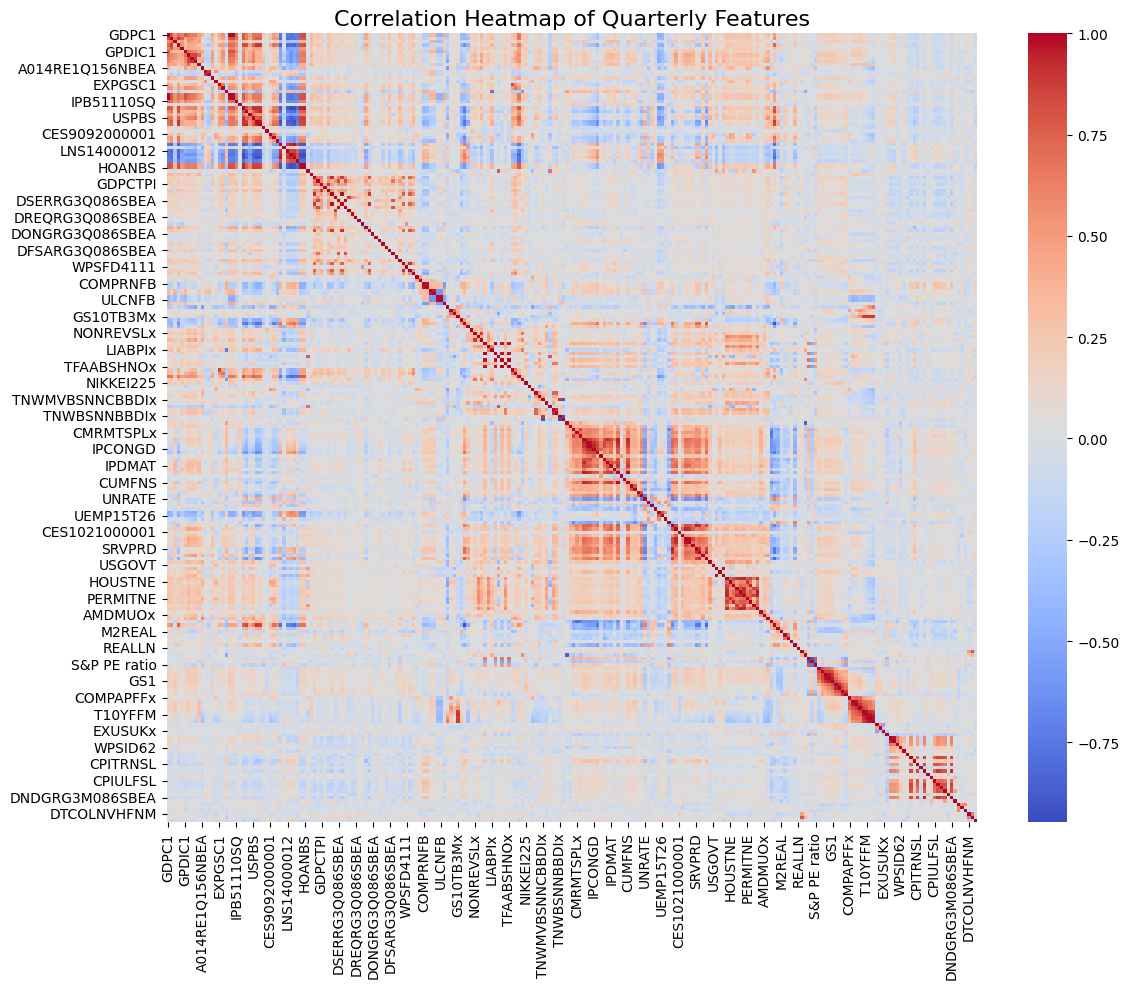

In [221]:
import seaborn as sns

import matplotlib.pyplot as plt

# Calculate the correlation matrix for the quarterly_features DataFrame
correlation_matrix = combined_data.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Generate a heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", cbar=True)

# Add title
plt.title("Correlation Heatmap of Quarterly Features", fontsize=16)

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

# Define the target variable (e.g., 'GDP')
target_variable = 'GDPC1'

# Initialize a dictionary to store the results
granger_results = {}

# Loop through each feature in the dataset
for feature in combined_data.columns:
    if feature != target_variable:  # Skip the target variable itself
        # Prepare the data for Granger causality test
        data = combined_data[[target_variable, feature]].dropna()
        
        # Perform Granger causality test with a maximum lag of 20
        try:
            result = grangercausalitytests(data, maxlag=50)
            # Store the p-values for each lag
            granger_results[feature] = [round(result[lag][0]['ssr_chi2test'][1], 4) for lag in range(1, 51)]
        except Exception as e:
            print(f"Error testing feature {feature}: {e}")

# Display the results
print("Granger Causality Test Results (p-values):")
for feature, p_values in granger_results.items():
    print(f"{feature}: {p_values}")

c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not p

Granger Causality Test Results (p-values):
PCECC96: [np.float64(0.2237), np.float64(0.3625), np.float64(0.2947), np.float64(0.3684), np.float64(0.1683), np.float64(0.2424), np.float64(0.2207), np.float64(0.1794), np.float64(0.2238), np.float64(0.2115), np.float64(0.2776), np.float64(0.2379), np.float64(0.2274), np.float64(0.1234), np.float64(0.1591), np.float64(0.2213), np.float64(0.2231), np.float64(0.2033), np.float64(0.2497), np.float64(0.3158), np.float64(0.3469), np.float64(0.3606), np.float64(0.3625), np.float64(0.5386), np.float64(0.6655), np.float64(0.74), np.float64(0.767), np.float64(0.8729), np.float64(0.8681), np.float64(0.8747), np.float64(0.9087), np.float64(0.9191), np.float64(0.9217), np.float64(0.9201), np.float64(0.937), np.float64(0.9529), np.float64(0.9192), np.float64(0.8737), np.float64(0.8948), np.float64(0.9265), np.float64(0.8872), np.float64(0.892), np.float64(0.8431), np.float64(0.7594), np.float64(0.7401), np.float64(0.6204), np.float64(0.6805), np.float64(0

In [215]:
# Filter features with low p-values (e.g., below 0.05) from Granger causality test results
low_p_value_features = {feature: p_values for feature, p_values in granger_results.items() if any(p < 0.05 for p in p_values)}

print("Features with low p-values (below 0.05):")
for feature, p_values in low_p_value_features.items():
    print(f"{feature}: {p_values}")

Features with low p-values (below 0.05):
PCDGx: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
PCESVx: [np.float64(0.0941), np.float64(0.093), np.float64(0.1303), np.float64(0.2396), np.float64(0.

In [216]:
# Filter features with consistently low p-values (below 0.05 for all lags)
consistent_low_p_value_features = {
    feature: p_values for feature, p_values in granger_results.items() if all(p < 0.05 for p in p_values)
}

print("Features with consistently low p-values (below 0.05 for all lags):")
for feature, p_values in consistent_low_p_value_features.items():
    print(f"{feature}: {p_values}")

Features with consistently low p-values (below 0.05 for all lags):
PCDGx: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
FPIx: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), 

C:\Users\giada\AppData\Local\Temp\ipykernel_19444\3835860904.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


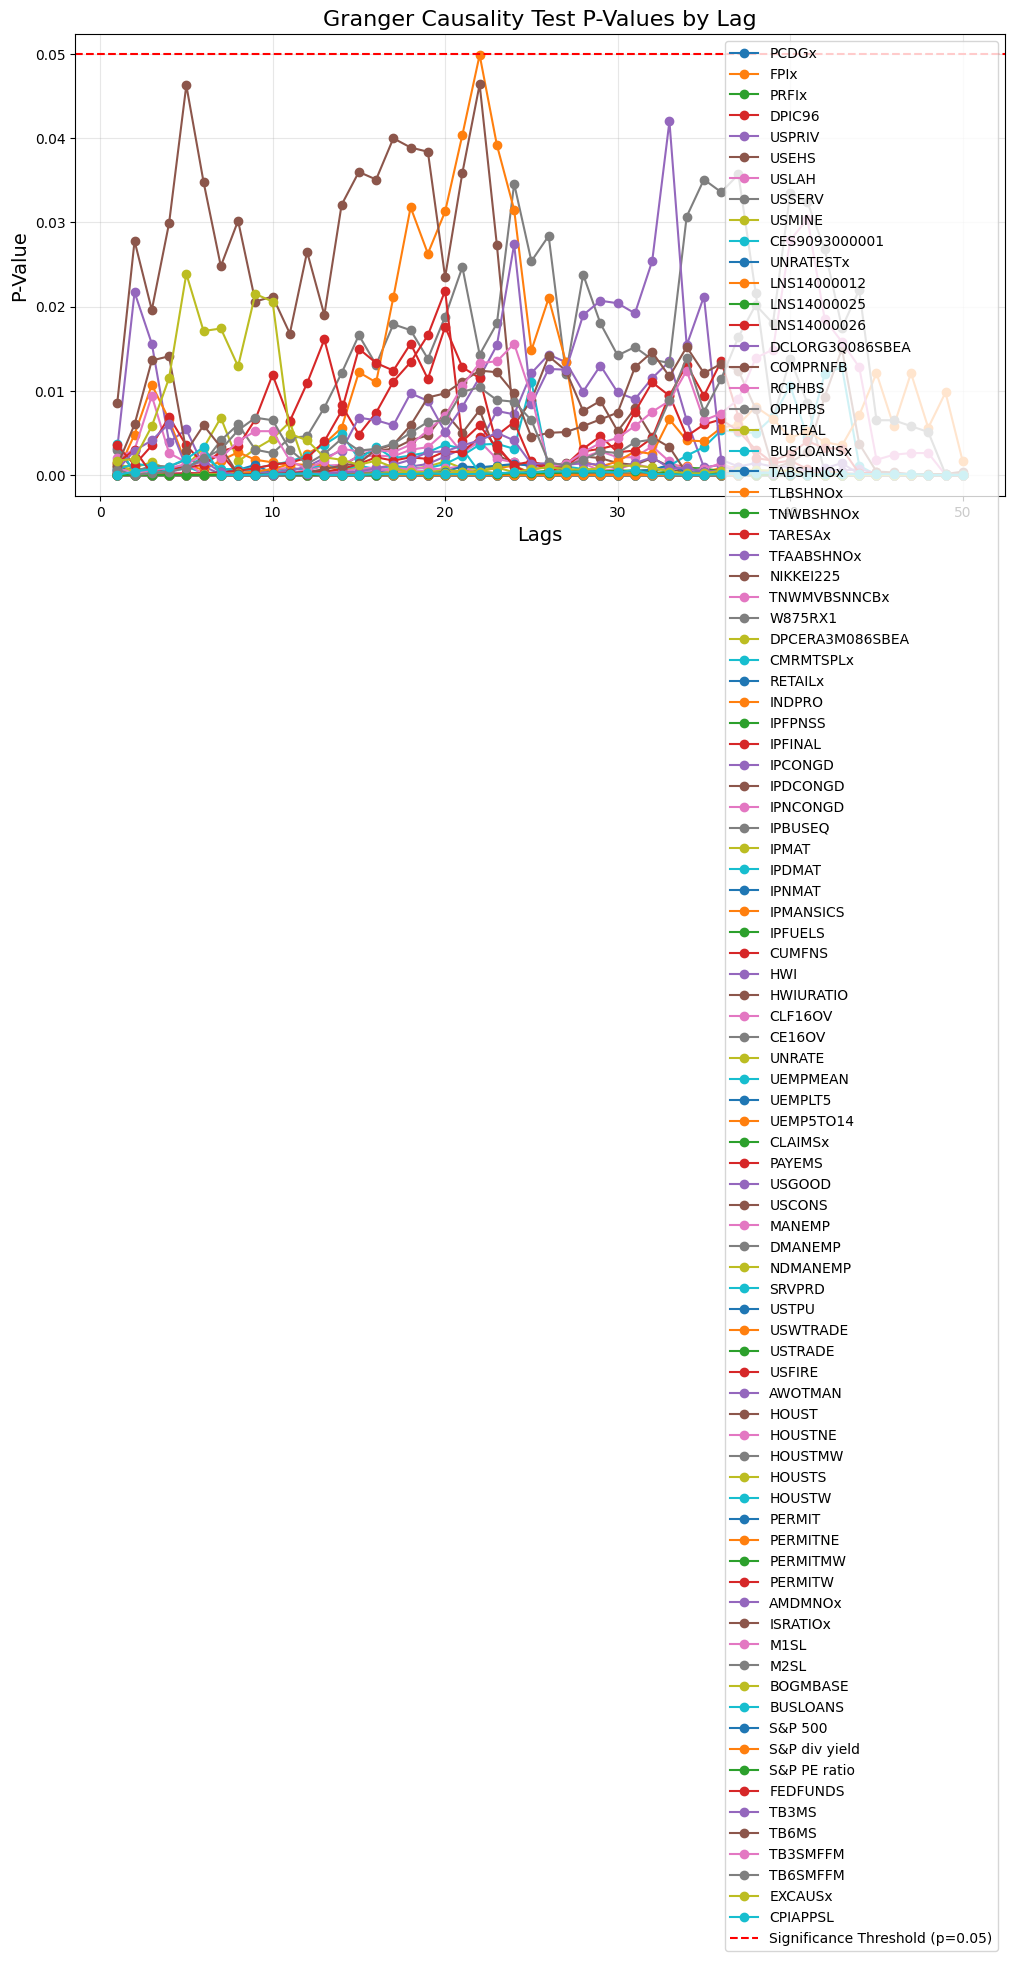

In [217]:
import matplotlib.pyplot as plt

# Define the significance threshold
significance_threshold = 0.05

# Set the maximum lags to match the available p-values
max_lag = 50  # Adjusted to match the number of lags in granger_results

# Prepare the data for plotting
features_to_plot = consistent_low_p_value_features.keys()  # Replace with the features you want to plot
p_values_data = {feature: granger_results[feature][:max_lag] for feature in features_to_plot}

# Plot the p-values for each feature
plt.figure(figsize=(12, 6))

for feature, p_values in p_values_data.items():
    plt.plot(range(1, max_lag + 1), p_values, marker='o', label=feature)

# Add the significance threshold line
plt.axhline(y=significance_threshold, color='red', linestyle='--', label='Significance Threshold (p=0.05)')

# Add labels, title, and legend
plt.xlabel('Lags', fontsize=14)
plt.ylabel('P-Value', fontsize=14)
plt.title('Granger Causality Test P-Values by Lag', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

In [218]:
# Calculate the percentage of consistently significant features
total_features = len(granger_results)
consistently_significant_features = len(consistent_low_p_value_features)
percentage_significant = (consistently_significant_features / total_features) * 100

print(f"Percentage of consistently significant features: {percentage_significant:.2f}%")

Percentage of consistently significant features: 37.97%


In [1]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests

# Assuming df has two columns: ['GDP', 'X'] with stationary monthly data
results = grangercausalitytests(combined_data[['GDP', 'OUTNFB']], maxlag=12, verbose=True)


NameError: name 'combined_data' is not defined

## Analysis of Regime Transitions

In this section, we will analyze the transitions between different regimes identified by the Markov-Switching Model. Understanding these transitions can provide insights into economic turning points and the impact of external events.

In [170]:
# Helper function to identify consecutive date ranges
def find_consecutive_periods(dates):
    if len(dates) == 0:
        return []
        
    # Sort the dates
    sorted_dates = sorted(dates)
    
    # Initialize the results
    periods = []
    start_date = sorted_dates[0]
    prev_date = sorted_dates[0]
    
    # Find consecutive periods
    for current_date in sorted_dates[1:]:
        # If dates are not consecutive quarters (more than 100 days apart)
        if (current_date - prev_date).days > 100:
            periods.append((start_date, prev_date))
            start_date = current_date
        prev_date = current_date
    
    # Add the last period
    periods.append((start_date, prev_date))
    
    return periods

# Calculate the average duration of each regime
avg_duration_regime0 = 1 / (1 - msm_result.regime_transition[0, 0].item())
avg_duration_regime1 = 1 / (1 - msm_result.regime_transition[1, 1].item())
avg_duration_regime2 = 1 / (1 - msm_result.regime_transition[2, 2].item())
avg_duration_regime3 = 1 / (1 - msm_result.regime_transition[3, 3].item())

print(f"Average duration of Regime 0 (Recession): {avg_duration_regime0:.2f} quarters")
print(f"Average duration of Regime 1 (Moderate Growth): {avg_duration_regime1:.2f} quarters")
print(f"Average duration of Regime 2 (High Growth): {avg_duration_regime2:.2f} quarters")
print(f"Average duration of Regime 3 (Crisis/Volatile): {avg_duration_regime3:.2f} quarters")

# Find periods where each regime had highest probability
regime_dates = {}
for i in range(4):
    # Get dates where this regime had the highest probability
    regime_prob = msm_result.smoothed_marginal_probabilities[i]
    regime_dominant = (regime_prob > 0.5)
    regime_dates[i] = gdp_series.index[regime_dominant]
    
    # Print some notable periods
    print(f"\nPeriods dominated by Regime {i}:")
    if len(regime_dates[i]) > 0:
        for start, end in find_consecutive_periods(regime_dates[i]):
            if (end - start).days > 90:  # Only show longer periods
                print(f"  {start.strftime('%Y-%m')} to {end.strftime('%Y-%m')}")

Average duration of Regime 0 (Recession): 1.00 quarters
Average duration of Regime 1 (Moderate Growth): 20.70 quarters
Average duration of Regime 2 (High Growth): 1.93 quarters
Average duration of Regime 3 (Crisis/Volatile): 7.37 quarters

Periods dominated by Regime 0:

Periods dominated by Regime 1:
  1984-12 to 1990-06
  1991-09 to 1997-12
  2002-03 to 2007-12
  2009-12 to 2019-12
  2022-09 to 2024-12

Periods dominated by Regime 2:
  1969-12 to 1970-06
  1974-09 to 1975-03
  1979-03 to 1979-06
  1980-06 to 1980-09
  1982-09 to 1982-12
  1990-09 to 1991-03
  2008-09 to 2009-06

Periods dominated by Regime 3:
  1959-06 to 1960-03
  1961-03 to 1969-03
  1971-03 to 1973-06
  1975-06 to 1977-09
  1978-09 to 1978-12
  1983-03 to 1984-09
  1998-03 to 2000-06
  2020-12 to 2021-12


### Visualizing GDP Growth by Regime

We can visualize the GDP growth rates categorized by the most probable regime to better understand the economic patterns detected by our model.


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


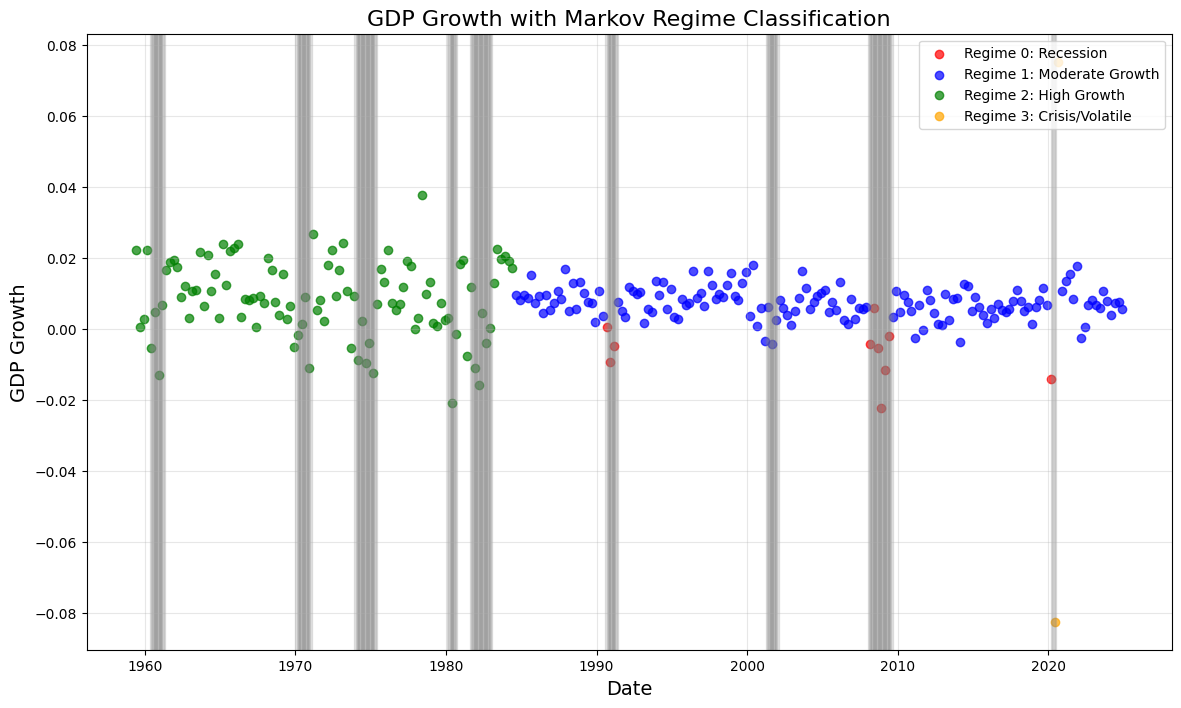

Summary Statistics by Regime:

Regime 0 (Recession)
Number of quarters: 10
Mean GDP growth: -0.006613
Std Dev: 0.007958
Min: -0.022133
Max: 0.005937

Regime 1 (Moderate Growth)
Number of quarters: 150
Mean GDP growth: 0.007538
Std Dev: 0.004351
Min: -0.004014
Max: 0.018049

Regime 2 (High Growth)
Number of quarters: 101
Mean GDP growth: 0.008825
Std Dev: 0.010666
Min: -0.020820
Max: 0.037920

Regime 3 (Crisis/Volatile)
Number of quarters: 2
Mean GDP growth: -0.003502
Std Dev: 0.111568
Min: -0.082393
Max: 0.075388


In [164]:
%pip install pandas-datareader

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas_datareader import data as pdr

# Create a dataframe with GDP growth and regime probabilities
regime_probs_df = pd.DataFrame({
    'GDP': gdp_series,
    'Regime_0': msm_result.smoothed_marginal_probabilities[0],
    'Regime_1': msm_result.smoothed_marginal_probabilities[1],
    'Regime_2': msm_result.smoothed_marginal_probabilities[2],
    'Regime_3': msm_result.smoothed_marginal_probabilities[3]
})

# Add a column with the most probable regime
regime_cols = ['Regime_0', 'Regime_1', 'Regime_2', 'Regime_3']
regime_probs_df['Most_Probable_Regime'] = regime_probs_df[regime_cols].idxmax(axis=1).apply(lambda x: int(x[-1]))

# Plot GDP with points colored by regime
plt.figure(figsize=(14, 8))

# Define colors for each regime
colors = ['red', 'blue', 'green', 'orange']
regime_names = ['Recession', 'Moderate Growth', 'High Growth', 'Crisis/Volatile']

# Plot each regime separately
for i in range(4):
    regime_data = regime_probs_df[regime_probs_df['Most_Probable_Regime'] == i]
    plt.scatter(regime_data.index, regime_data['GDP'], 
                color=colors[i], label=f'Regime {i}: {regime_names[i]}', alpha=0.7)

# Add recession bars (NBER recessions)
from pandas_datareader import data as pdr
try:
    # Try to get NBER recession data for comparison
    usrec = pdr.get_data_fred('USREC', start='1959-01-01', end='2024-12-31')
    rec_dates = usrec[usrec['USREC'] == 1].index
    for date in rec_dates:
        plt.axvspan(date, date + pd.DateOffset(months=3), color='gray', alpha=0.2)
except:
    print("Could not retrieve NBER recession data. Continuing without recession bars.")

plt.title('GDP Growth with Markov Regime Classification', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('GDP Growth', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Display summary statistics for each regime
print("Summary Statistics by Regime:")
for i in range(4):
    regime_data = regime_probs_df[regime_probs_df['Most_Probable_Regime'] == i]
    if not regime_data.empty:
        print(f"\nRegime {i} ({regime_names[i]})")
        print(f"Number of quarters: {len(regime_data)}")
        print(f"Mean GDP growth: {regime_data['GDP'].mean():.6f}")
        print(f"Std Dev: {regime_data['GDP'].std():.6f}")
        print(f"Min: {regime_data['GDP'].min():.6f}")
        print(f"Max: {regime_data['GDP'].max():.6f}")

### Analysis of Transition Periods

Let's analyze when the economy transitioned between regimes. This can provide insights into economic turning points.

Major Regime Transitions:
1990-09: Moderate Growth → Recession
1991-06: Recession → Moderate Growth
2008-03: Moderate Growth → Recession
2009-09: Recession → Moderate Growth
2020-03: Moderate Growth → Recession
2020-06: Recession → Crisis/Volatile
2020-12: Crisis/Volatile → Moderate Growth


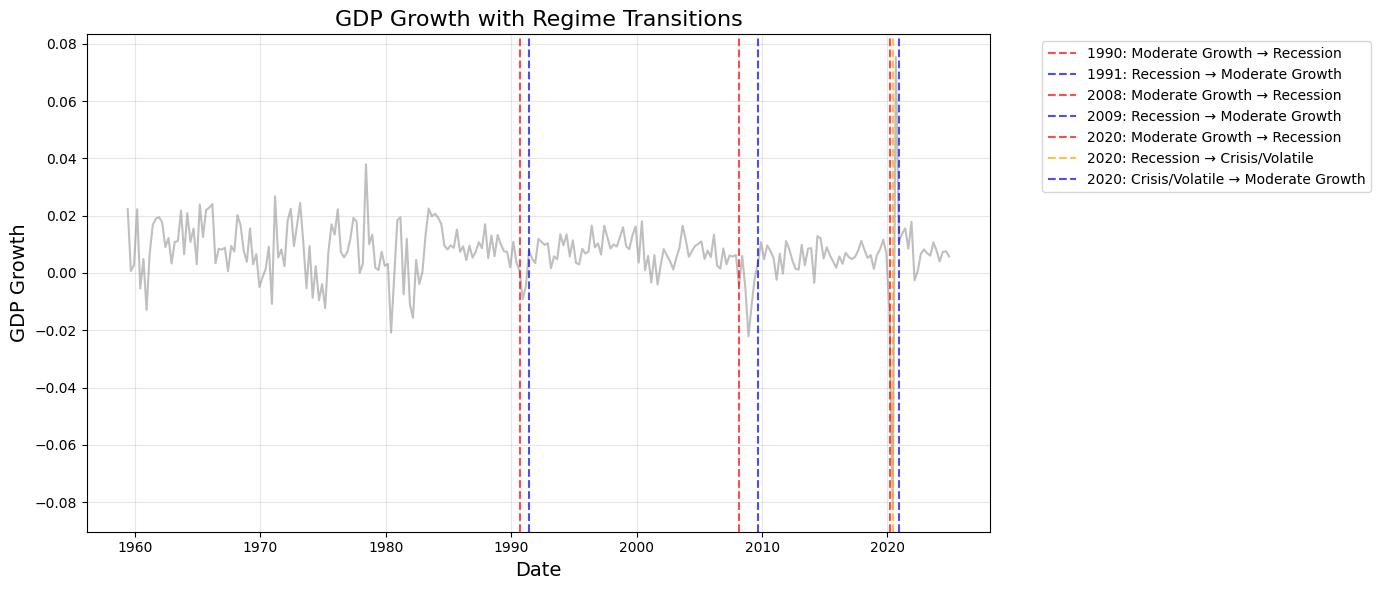

In [165]:
# Identify transitions between regimes
regime_probs_df['Regime_Change'] = regime_probs_df['Most_Probable_Regime'].diff().abs() > 0
transitions = regime_probs_df[regime_probs_df['Regime_Change']].copy()

# Add information about previous regime
transitions['Previous_Regime'] = transitions['Most_Probable_Regime'].shift(1)

# Filter out the first row (which has NaN for Previous_Regime)
transitions = transitions.dropna(subset=['Previous_Regime'])
transitions['Previous_Regime'] = transitions['Previous_Regime'].astype(int)

# Display the regime transitions
print("Major Regime Transitions:")
for idx, row in transitions.iterrows():
    prev_regime = int(row['Previous_Regime'])
    curr_regime = row['Most_Probable_Regime']
    print(f"{idx.strftime('%Y-%m')}: {regime_names[prev_regime]} → {regime_names[curr_regime]}")

# Plot transitions over time
plt.figure(figsize=(14, 6))

# Plot GDP series
plt.plot(regime_probs_df.index, regime_probs_df['GDP'], color='gray', alpha=0.5)

# Add vertical lines for regime transitions
for idx, row in transitions.iterrows():
    prev_regime = int(row['Previous_Regime'])
    curr_regime = row['Most_Probable_Regime']
    plt.axvline(x=idx, color=colors[curr_regime], linestyle='--', alpha=0.7,
               label=f"{idx.year}: {regime_names[prev_regime]} → {regime_names[curr_regime]}")

# Remove duplicate labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1.05, 1))

plt.title('GDP Growth with Regime Transitions', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('GDP Growth', fontsize=14)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()